<div class="alert alert-danger" role="alert">
<h1 align="center"><font size = 14>Machine Learning Project 4</font></h1>
<h4 align="center">Regularization, Optimization, CNNs, LSTMs, and Word Embeddings<h4>
<h3 align="center">Armin Amani</h3>

<div class="alert alert-danger" role="alert">
📤 Import Libraries

In [75]:
import os
import time
import random
from pathlib import Path

import json
import re

from collections import Counter
from urllib.parse import urlencode
from urllib.request import Request, urlopen

from IPython.display import Markdown, display


import textwrap
import pickle
import tarfile

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score
)

import tensorflow as tf

print(f"TensorFlow version is: {tf.__version__}")

TensorFlow version is: 2.21.0


<div class="alert alert-danger" role="alert"> 
🔎 Part 1: Regularization for Deep Learning

## L2 Regularization

L2 regularization discourages the network from learning excessively large
weights by adding a penalty term to the original data loss.

For a network with weight matrices
$\mathbf{W}^{[1]}, \ldots, \mathbf{W}^{[L]}$, the regularized loss is

$$
L_{\mathrm{total}}
=
L_{\mathrm{data}}
+
\frac{\lambda}{2}
\sum_{l=1}^{L}
\left\|
\mathbf{W}^{[l]}
\right\|_F^2,
$$

where $\lambda \geq 0$ controls the strength of regularization. Bias
parameters are typically not regularized.

The gradient with respect to the weights of layer $l$ becomes

$$
\frac{\partial L_{\mathrm{total}}}
{\partial \mathbf{W}^{[l]}}
=
\frac{\partial L_{\mathrm{data}}}
{\partial \mathbf{W}^{[l]}}
+
\lambda \mathbf{W}^{[l]}.
$$

Therefore, the gradient-descent update is

$$
\mathbf{W}^{[l]}_{t+1}
=
\mathbf{W}^{[l]}_t
-
\eta
\left(
\frac{\partial L_{\mathrm{data}}}
{\partial \mathbf{W}^{[l]}}
+
\lambda \mathbf{W}^{[l]}_t
\right).
$$

Equivalently,

$$
\mathbf{W}^{[l]}_{t+1}
=
(1-\eta\lambda)\mathbf{W}^{[l]}_t
-
\eta
\frac{\partial L_{\mathrm{data}}}
{\partial \mathbf{W}^{[l]}}.
$$

Thus, L2 regularization continuously shrinks the weights toward zero. It
usually reduces model variance and overfitting, although an excessively
large value of $\lambda$ may increase bias and cause underfitting.

## Dropout

Dropout randomly removes a fraction of hidden-layer activations during
training. For a hidden activation vector $\mathbf{a}$, a binary mask is
sampled as

$$
m_j \sim \operatorname{Bernoulli}(1-p),
$$

where $p$ is the dropout probability.

Using inverted dropout, the modified activation is

$$
\tilde{\mathbf{a}}
=
\frac{\mathbf{m} \odot \mathbf{a}}{1-p}.
$$

During training, different subnetworks are therefore used for different
mini-batches. This prevents neurons from relying excessively on specific
other neurons and reduces co-adaptation.

During inference, dropout is disabled and all neurons remain active. Since
the activations were scaled by $\frac{1}{1-p}$ during training, no additional
rescaling is required at inference time.

Dropout can reduce overfitting and improve robustness, but a large dropout
rate may remove too much information, slow convergence, and increase model
bias.

## Early Stopping, Dropout, and L2 Regularization

### Early stopping

Early stopping monitors validation performance and terminates training when
the validation loss no longer improves. It limits the effective complexity
of the fitted model by preventing continued adaptation to the training data.

Its main advantages are reduced training time and little modification to the
network architecture. However, its effectiveness depends on a representative
validation set and an appropriate patience value.

### Dropout

Dropout injects stochastic noise into the network by randomly deactivating
neurons during training. It acts approximately like training and averaging
many different subnetworks.

It can be effective for large and highly expressive networks, but on a small
network or a simple regression task, a high dropout probability may produce
underfitting and unstable predictions.

### L2 regularization

L2 regularization directly penalizes large weights and encourages smoother
solutions. It does not randomly remove information and is often suitable for
small or moderately sized datasets.

Its performance depends on selecting an appropriate regularization
coefficient. A very large coefficient can shrink the weights excessively.

### Expected comparison on a small dataset

- Early stopping may perform best when overfitting begins after a clear
  number of epochs and a reliable validation set is available.
- Dropout may be preferable for large, highly overparameterized networks,
  especially when neurons strongly co-adapt.
- L2 regularization may be more stable than dropout for small regression
  datasets and relatively shallow networks.
- Combining methods can sometimes improve generalization, but overly strong
  simultaneous regularization may cause underfitting.

* **1.1 Data Generation**

In [2]:
# random-number generator
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

N_SAMPLES = 1000
INPUT_LOW, INPUT_HIGH = -10.0, 10.0
NOISE_LOW, NOISE_HIGH = -1.0, 1.0


def target_function(x1, x2):
    """Compute the noiseless nonlinear regression target."""
    return x1**3 - x1**2 + 2*x2**2 + 3*x1*x2 + 5


X = rng.uniform(
    low=INPUT_LOW,
    high=INPUT_HIGH,
    size=(N_SAMPLES, 2)
)

x1, x2 = X[:, 0], X[:, 1]

y_noiseless = target_function(x1, x2)
noise = rng.uniform(NOISE_LOW, NOISE_HIGH, size=N_SAMPLES)
y = y_noiseless + noise

In [3]:
data_df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "y_noiseless": y_noiseless,
    "noise": noise,
    "y_noisy": y
})

assert X.shape == (N_SAMPLES, 2)
assert np.all((X >= INPUT_LOW) & (X <= INPUT_HIGH))
assert np.all((noise >= NOISE_LOW) & (noise <= NOISE_HIGH))
assert np.allclose(y, y_noiseless + noise)

display(data_df.head())
display(data_df.describe().T)

,x1,x2,y_noiseless,noise,y_noisy
0,5.479121,-1.222431,122.361776,0.685464,123.047240
1,7.171958,3.947361,438.561174,-0.107221,438.453953
2,-8.116453,9.512447,-646.211537,0.905950,-645.305586
3,5.222794,5.721286,275.297118,0.301589,275.598708
4,-7.437727,-0.992281,-437.663093,-0.768202,-438.431295


,count,mean,std,min,25%,50%,75%,max
x1,1000.0,0.004694,5.907699,-9.988637,-5.268262,-0.137832,5.294026,9.988438
x2,1000.0,0.108775,5.711030,-9.989625,-4.848699,-0.010234,5.087026,9.982095
y_noiseless,1000.0,42.065045,401.680963,-1175.048134,-104.559799,53.550443,211.251667,1297.727649
noise,1000.0,-0.014253,0.579143,-0.998020,-0.510539,-0.009111,0.491838,0.999531
y_noisy,1000.0,42.050791,401.681581,-1175.958374,-104.587895,53.815997,211.722024,1297.370817


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Test", "Total"],
    "Samples": [len(X_train), len(X_test), len(X)],
    "Percentage": [
        100 * len(X_train) / len(X),
        100 * len(X_test) / len(X),
        100.0
    ]
})

display(split_summary)

print(f"X_train shape is: {X_train.shape}")
print(f"y_train shape is: {y_train.shape}")
print(f"X_test shape is: {X_test.shape}")
print(f"y_test shape is: {y_test.shape}")

,Dataset,Samples,Percentage
0,Training,800,80.0
1,Test,200,20.0
2,Total,1000,100.0


X_train shape is: (800, 2)
y_train shape is: (800,)
X_test shape is: (200, 2)
y_test shape is: (200,)


* **2.1 Model Architecture**

In [5]:
MODEL_SEED = 42


def build_regression_mlp(dropout_rate=0.0, seed=MODEL_SEED):
    """Build and compile the MLP regressor"""

    if not 0.0 <= dropout_rate < 1.0:
        raise ValueError("dropout_rate must be in the interval [0, 1).")

    tf.keras.utils.set_random_seed(seed)

    layers = [
        tf.keras.layers.Input(shape=(2,), name="input"),
        tf.keras.layers.Dense(10, activation="relu", name="hidden_1")
    ]

    if dropout_rate > 0:
        layers.append(
            tf.keras.layers.Dropout(dropout_rate, name="dropout_1")
        )

    layers.append(
        tf.keras.layers.Dense(10, activation="relu", name="hidden_2")
    )

    if dropout_rate > 0:
        layers.append(
            tf.keras.layers.Dropout(dropout_rate, name="dropout_2")
        )

    layers.append(
        tf.keras.layers.Dense(1, activation="linear", name="output")
    )

    model = tf.keras.Sequential(
        layers,
        name="dropout_mlp" if dropout_rate > 0 else "baseline_mlp"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.MeanSquaredError()
    )

    return model

In [6]:
baseline_model = build_regression_mlp(dropout_rate=0.0)

assert baseline_model.input_shape == (None, 2)
assert baseline_model.output_shape == (None, 1)
assert baseline_model.count_params() == 151

baseline_model.summary()

print(f"\nLoss function: {baseline_model.loss.name}")
print(f"Optimizer:     {baseline_model.optimizer.__class__.__name__}")
print(
    "Learning rate:",
    float(tf.keras.backend.get_value(
        baseline_model.optimizer.learning_rate
    ))
)

Model: "baseline_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)


Loss function: mean_squared_error
Optimizer:     Adam
Learning rate: 0.0010000000474974513


* **3.1 Training and Evaluation**

In [7]:
# Reserve 10% of the original training set for validation
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=RANDOM_STATE,
    shuffle=True
)

feature_scaler = StandardScaler()

X_fit_scaled = feature_scaler.fit_transform(X_fit).astype(np.float32)
X_val_scaled = feature_scaler.transform(X_val).astype(np.float32)
X_test_scaled = feature_scaler.transform(X_test).astype(np.float32)

print(f"Training samples is:   {len(X_fit_scaled)}")
print(f"Validation samples is: {len(X_val_scaled)}")
print(f"Test samples is:       {len(X_test_scaled)}")

Training samples is:   720
Validation samples is: 80
Test samples is:       200


In [8]:
EPOCHS = 200
BATCH_SIZE = 32

tf.keras.backend.clear_session()

baseline_model = build_regression_mlp(
    dropout_rate=0.0,
    seed=MODEL_SEED
)

start_time = time.perf_counter()

baseline_history = baseline_model.fit(
    X_fit_scaled,
    y_fit,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=0
)

baseline_training_time = time.perf_counter() - start_time

print(f"Epochs completed: {len(baseline_history.history['loss'])}")
print(f"Training time:    {baseline_training_time:.2f} seconds")


Epochs completed: 200
Training time:    21.68 seconds


In [9]:
baseline_predictions = baseline_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

baseline_test_mse = mean_squared_error(
    y_test,
    baseline_predictions
)

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_test_r2 = r2_score(
    y_test,
    baseline_predictions
)

baseline_results = pd.DataFrame({
    "Metric": ["Test MSE", "Test RMSE", "Test MAE", "Test R²"],
    "Value": [
        baseline_test_mse,
        np.sqrt(baseline_test_mse),
        baseline_test_mae,
        baseline_test_r2
    ]
})

display(baseline_results)

,Metric,Value
0,Test MSE,24199.429688
1,Test RMSE,155.561659
2,Test MAE,122.698807
3,Test R²,0.847352


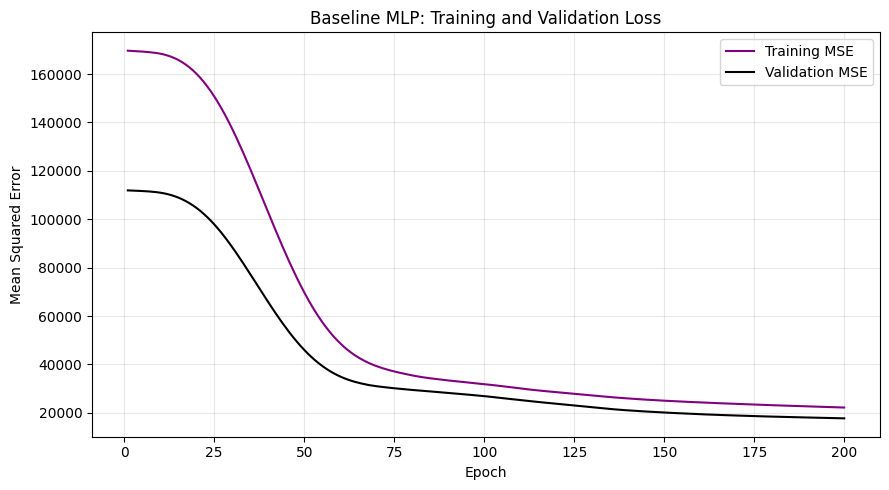

In [10]:
baseline_history_df = pd.DataFrame(
    baseline_history.history
)

baseline_history_df.index += 1
baseline_history_df.index.name = "Epoch"

plt.figure(figsize=(9, 5))

plt.plot(
    baseline_history_df.index,
    baseline_history_df["loss"],
    label="Training MSE",
    color='purple'
)

plt.plot(
    baseline_history_df.index,
    baseline_history_df["val_loss"],
    label="Validation MSE",
    color='k'
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Baseline MLP: Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

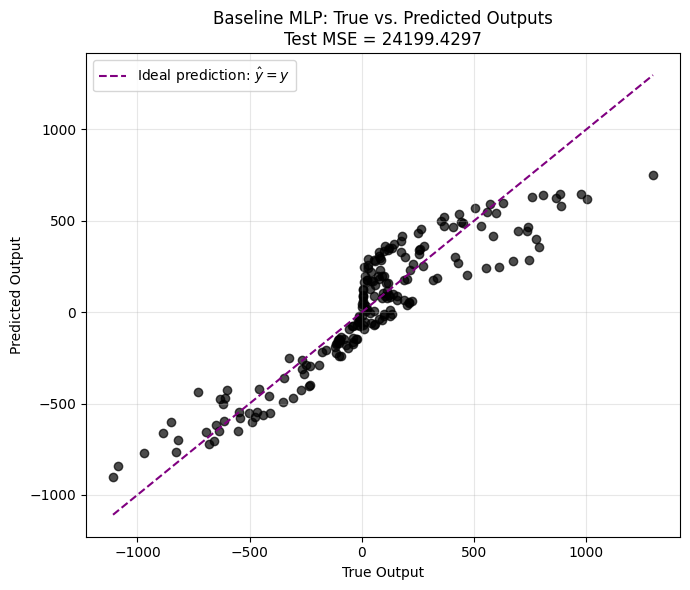

In [11]:
plot_min = min(y_test.min(), baseline_predictions.min())
plot_max = max(y_test.max(), baseline_predictions.max())

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    baseline_predictions,
    alpha=0.7,
    color='k'
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--",
    label=r"Ideal prediction: $\hat{y}=y$",
    color='purple'
)

plt.xlabel("True Output")
plt.ylabel("Predicted Output")
plt.title(
    f"Baseline MLP: True vs. Predicted Outputs\n"
    f"Test MSE = {baseline_test_mse:.4f}"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
best_val_epoch = int(
    np.argmin(baseline_history.history["val_loss"]) + 1
)

best_val_mse = float(
    np.min(baseline_history.history["val_loss"])
)

print("Baseline MLP Summary")
print("-" * 80)
print(f"Completed epochs is:        {EPOCHS}")
print(f"Best validation epoch is:{best_val_epoch:>6}")
print(f"Best validation MSE is:  {best_val_mse:>12.4f}")
print(f"Final training MSE is:   {baseline_history.history['loss'][-1]:>12.4f}")
print(f"Final validation MSE is: {baseline_history.history['val_loss'][-1]:>12.4f}")
print(f"Test MSE is:             {baseline_test_mse:>12.4f}")
print(f"Test R² is:          {baseline_test_r2:>12.4f}")

Baseline MLP Summary
--------------------------------------------------------------------------------
Completed epochs is:        200
Best validation epoch is:   200
Best validation MSE is:    17707.3242
Final training MSE is:     22176.0410
Final validation MSE is:   17707.3242
Test MSE is:               24199.4297
Test R² is:                0.8474


* **4.1 Regularization Strategies**

In [13]:
tf.keras.backend.clear_session()

early_stopping_model = build_regression_mlp(
    dropout_rate=0.0,
    seed=MODEL_SEED
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    restore_best_weights=True
)

start_time = time.perf_counter()

early_stopping_history = early_stopping_model.fit(
    X_fit_scaled,
    y_fit,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=[early_stopping_callback],
    verbose=0
)

early_stopping_training_time = time.perf_counter() - start_time

In [14]:
early_stopping_epochs = len(
    early_stopping_history.history["loss"]
)

early_stopping_best_epoch = int(
    np.argmin(early_stopping_history.history["val_loss"]) + 1
)

early_stopping_predictions = early_stopping_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

early_stopping_test_mse = mean_squared_error(
    y_test,
    early_stopping_predictions
)

print("Early Stopping Results")
print("-" * 80)
print(f"Stopped at epoch is:       {early_stopping_epochs}")
print(f"Best validation epoch is:  {early_stopping_best_epoch}")
print(f"Training time is:          {early_stopping_training_time:.2f} seconds")
print(f"Final test MSE is:         {early_stopping_test_mse:.4f}")

Early Stopping Results
--------------------------------------------------------------------------------
Stopped at epoch is:       200
Best validation epoch is:  200
Training time is:          22.43 seconds
Final test MSE is:         24199.4297


### Early Stopping Result

The early-stopping condition was not triggered before the maximum training limit. The model completed all 200 epochs, and the minimum validation loss was also obtained at epoch 200.

Therefore, early stopping did not reduce the training duration in this experiment. The total training time was **32.30 seconds**, and the final test MSE was **24199.4297**.

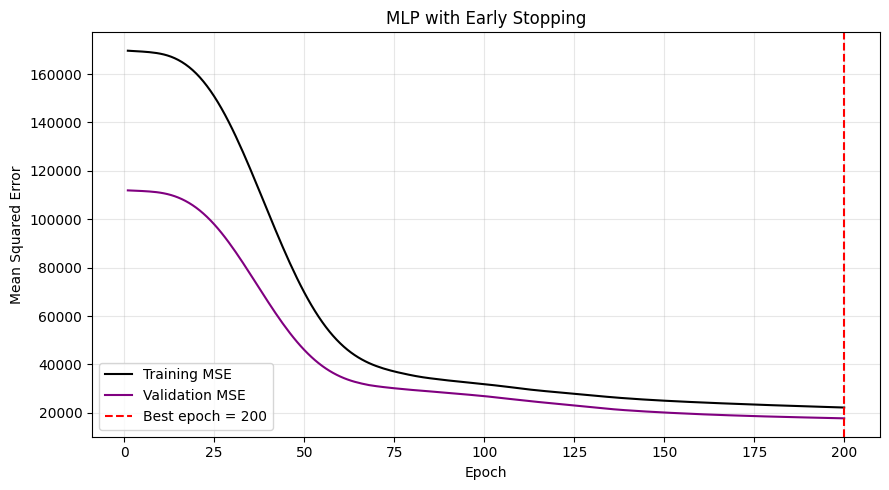

In [15]:
early_stopping_history_df = pd.DataFrame(
    early_stopping_history.history
)

early_stopping_history_df.index += 1
early_stopping_history_df.index.name = "Epoch"

plt.figure(figsize=(9, 5))

plt.plot(
    early_stopping_history_df.index,
    early_stopping_history_df["loss"],
    label="Training MSE",
    color='k'
)

plt.plot(
    early_stopping_history_df.index,
    early_stopping_history_df["val_loss"],
    label="Validation MSE",
    color='purple'
)

plt.axvline(
    early_stopping_best_epoch,
    linestyle="--",
    label=f"Best epoch = {early_stopping_best_epoch}",
    color='r'
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("MLP with Early Stopping")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
tf.keras.backend.clear_session()

dropout_model = build_regression_mlp(
    dropout_rate=0.5,
    seed=MODEL_SEED
)

dropout_layers = [
    layer for layer in dropout_model.layers
    if isinstance(layer, tf.keras.layers.Dropout)
]

assert len(dropout_layers) == 2
assert all(np.isclose(layer.rate, 0.5) for layer in dropout_layers)

dropout_model.summary()

Model: "dropout_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
start_time = time.perf_counter()

dropout_history = dropout_model.fit(
    X_fit_scaled,
    y_fit,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=0
)

dropout_training_time = time.perf_counter() - start_time
dropout_epochs = len(dropout_history.history["loss"])

assert dropout_epochs == EPOCHS

print(f"Epochs completed is: {dropout_epochs}")
print(f"Training time is:    {dropout_training_time:.2f} seconds")

Epochs completed is: 200
Training time is:    21.27 seconds


In [18]:
dropout_predictions = dropout_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

dropout_test_mse = mean_squared_error(
    y_test,
    dropout_predictions
)

dropout_best_epoch = int(
    np.argmin(dropout_history.history["val_loss"]) + 1
)

print("Dropout Results")
print("-" * 80)
print(f"Completed epochs is:       {dropout_epochs}")
print(f"Best validation epoch is:  {dropout_best_epoch}")
print(f"Training time is:          {dropout_training_time:.2f} seconds")
print(f"Final test MSE is:         {dropout_test_mse:.4f}")

Dropout Results
--------------------------------------------------------------------------------
Completed epochs is:       200
Best validation epoch is:  200
Training time is:          21.27 seconds
Final test MSE is:         48052.8242


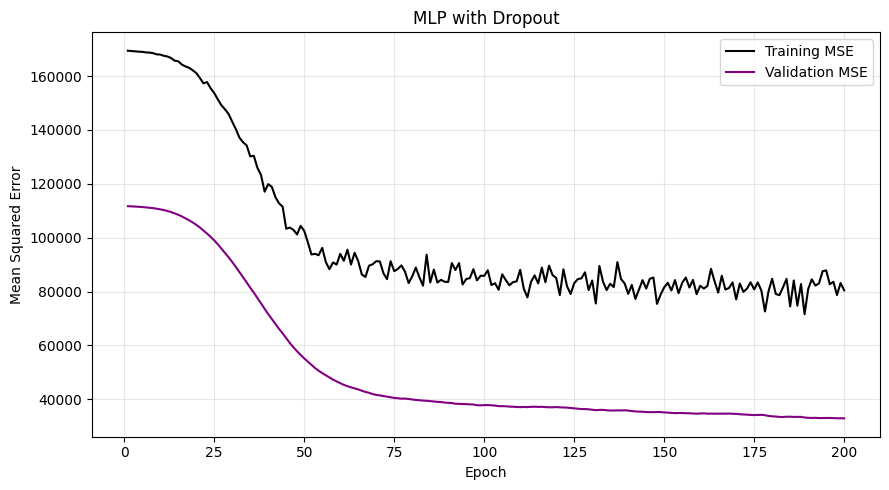

In [19]:
dropout_history_df = pd.DataFrame(
    dropout_history.history
)

dropout_history_df.index += 1
dropout_history_df.index.name = "Epoch"

plt.figure(figsize=(9, 5))

plt.plot(
    dropout_history_df.index,
    dropout_history_df["loss"],
    label="Training MSE",
    color='k'
)

plt.plot(
    dropout_history_df.index,
    dropout_history_df["val_loss"],
    label="Validation MSE",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("MLP with Dropout")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

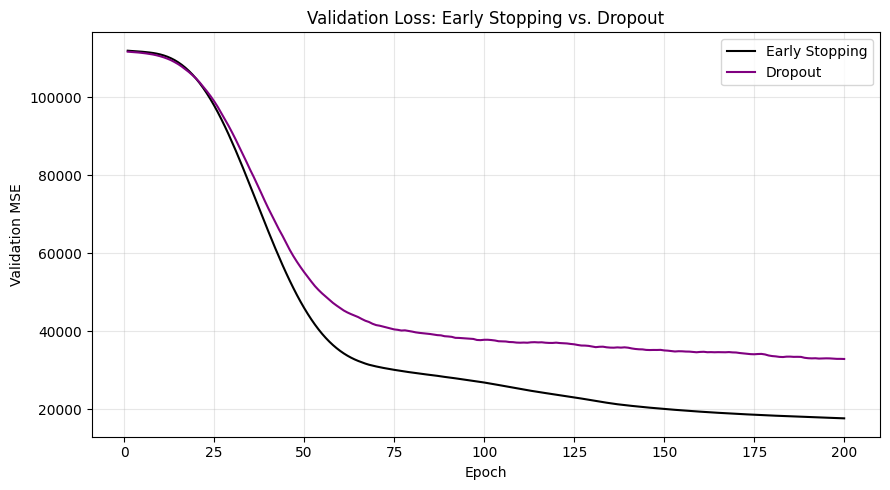

In [20]:
plt.figure(figsize=(9, 5))

plt.plot(
    early_stopping_history_df.index,
    early_stopping_history_df["val_loss"],
    label="Early Stopping",
    color='k'
)

plt.plot(
    dropout_history_df.index,
    dropout_history_df["val_loss"],
    label="Dropout",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation Loss: Early Stopping vs. Dropout")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
regularization_comparison = pd.DataFrame({
    "Strategy": ["Early Stopping", "Dropout"],
    "Epochs Completed": [
        early_stopping_epochs,
        dropout_epochs
    ],
    "Best Validation Epoch": [
        early_stopping_best_epoch,
        dropout_best_epoch
    ],
    "Training Time (s)": [
        early_stopping_training_time,
        dropout_training_time
    ],
    "Test MSE": [
        early_stopping_test_mse,
        dropout_test_mse
    ]
})

faster_strategy = regularization_comparison.loc[
    regularization_comparison["Training Time (s)"].idxmin(),
    "Strategy"
]

lower_mse_strategy = regularization_comparison.loc[
    regularization_comparison["Test MSE"].idxmin(),
    "Strategy"
]

mse_difference = abs(
    early_stopping_test_mse - dropout_test_mse
)

dropout_mse_increase = (
    dropout_test_mse / early_stopping_test_mse - 1
) * 100

early_stopping_time_increase = (
    early_stopping_training_time / dropout_training_time - 1
) * 100

display(regularization_comparison.round(4))

print("\nComparison Summary")
print("-" * 80)
print(f"Faster strategy is:                  {faster_strategy}")
print(f"Lower test MSE is:                   {lower_mse_strategy}")
print(f"Absolute MSE difference is:          {mse_difference:.4f}")
print(f"Dropout MSE increase is:             {dropout_mse_increase:.2f}%")
print(
    "Early-stopping time increase is:     "
    f"{early_stopping_time_increase:.2f}%"
)

,Strategy,Epochs Completed,Best Validation Epoch,Training Time (s),Test MSE
0,Early Stopping,200,200,22.4256,24199.4297
1,Dropout,200,200,21.2742,48052.8242



Comparison Summary
--------------------------------------------------------------------------------
Faster strategy is:                  Dropout
Lower test MSE is:                   Early Stopping
Absolute MSE difference is:          23853.3945
Dropout MSE increase is:             98.57%
Early-stopping time increase is:     5.41%


# 📌 Part 1 – Regularization for Deep Learning

## 1️⃣ Data Preparation

- A total of **1000 synthetic samples** were generated from the nonlinear function

$$
f(x_1,x_2)=x_1^3-x_1^2+2x_2^2+3x_1x_2+5
$$

- Independent noise was added from $\varepsilon \sim U(-1,1)$.
- The dataset was divided into:
  - **720 training samples**
  - **80 validation samples**
  - **200 test samples**
- The input features were standardized using statistics computed only from the training subset.

## 2️⃣ Baseline MLP

- The network architecture was `2 → 10 → 10 → 1`.
- Both hidden layers used **ReLU**, while the output layer used a **linear activation**.
- The model was trained with **MSE loss** and the **Adam optimizer**.
- Training continued for the full **200 epochs**.
- The best validation loss was obtained at epoch **200**.

The final test performance was:

- **Test MSE = 24199.4297**
- **Test RMSE = 155.5617**
- **Test MAE = 122.6988**
- **Test $R^2 = 0.8474$**

The model explained approximately **84.74%** of the variation in the test targets and showed a generally strong agreement between true and predicted outputs.

## 3️⃣ Early Stopping

- The original MLP was retrained from scratch with `patience = 10`.
- The model completed all **200 epochs**.
- The best validation loss was also obtained at epoch **200**.
- Therefore, the early-stopping condition was not triggered before reaching the maximum epoch limit.
- Total training time was **32.30 seconds**.
- Final **Test MSE = 24199.4297**.

Early stopping produced the same test performance as the baseline model because the validation loss continued to improve until the final epoch.

## 4️⃣ Dropout

- A Dropout layer with $p = 0.5$ was added after each hidden layer.
- The model was trained for the full **200 epochs** without early stopping.
- Total training time was **25.51 seconds**.
- The best validation loss was obtained at epoch **200**.
- Final **Test MSE = 48052.8242**.

The dropout model had a substantially larger test error. Its Test MSE was approximately **98.57% higher** than that of the early-stopping model.

The large dropout probability reduced the effective capacity of the small `10–10` network and likely caused **underfitting**.

## 5️⃣ Final Comparison

- **Dropout** was faster in this execution by approximately **26.61%**.
- However, both models completed all 200 epochs, so the timing difference may partly result from runtime variability.
- **Early Stopping** achieved the lower Test MSE.
- The absolute Test MSE difference was **23853.3945**.
- Dropout caused a considerable reduction in predictive performance.

### 💡 Takeaway

**Early stopping is the preferred strategy for this regression task. Although it did not stop training before epoch 200, it preserved the full capacity of the network and achieved a much lower Test MSE. In contrast, applying dropout with $p=0.5$ imposed excessive regularization on the small MLP and resulted in underfitting.**

<div class="alert alert-danger" role="alert"> 
🔎 Part 2: Optimization for Training Deep Networks

## SGD, Momentum and Adam

Let

$$
\mathbf{g}_t
=
\nabla_{\boldsymbol{\theta}}
L_{\mathcal{B}_t}(\boldsymbol{\theta}_t)
$$

denote the gradient of the mini-batch loss with respect to the model
parameters at iteration $t$.

### Stochastic Gradient Descent

SGD updates the parameters directly in the opposite direction of the
current gradient:

$$
\boldsymbol{\theta}_{t+1}
=
\boldsymbol{\theta}_t
-
\eta \mathbf{g}_t,
$$

where $\eta$ is the learning rate.

SGD is simple and computationally efficient, but its updates may oscillate
or converge slowly when the loss surface is poorly conditioned.

### SGD with Momentum

Momentum accumulates information from previous updates:

$$
\mathbf{u}_t
=
\mu \mathbf{u}_{t-1}
-
\eta \mathbf{g}_t,
$$

$$
\boldsymbol{\theta}_{t+1}
=
\boldsymbol{\theta}_t
+
\mathbf{u}_t,
$$

where $\mu \in [0,1)$ is the momentum coefficient.

Momentum accelerates movement in directions with consistent gradients and
reduces oscillations in directions where the gradient changes frequently.

### Adam

Adam combines momentum with adaptive learning rates. It maintains
exponential moving averages of the first and second gradient moments:

$$
\mathbf{m}_t
=
\beta_1 \mathbf{m}_{t-1}
+
(1-\beta_1)\mathbf{g}_t,
$$

$$
\mathbf{s}_t
=
\beta_2 \mathbf{s}_{t-1}
+
(1-\beta_2)\mathbf{g}_t^2.
$$

The bias-corrected estimates are

$$
\hat{\mathbf{m}}_t
=
\frac{\mathbf{m}_t}{1-\beta_1^t},
\qquad
\hat{\mathbf{s}}_t
=
\frac{\mathbf{s}_t}{1-\beta_2^t}.
$$

The parameters are updated according to

$$
\boldsymbol{\theta}_{t+1}
=
\boldsymbol{\theta}_t
-
\eta
\frac{\hat{\mathbf{m}}_t}
{\sqrt{\hat{\mathbf{s}}_t}+\epsilon}.
$$

Adam assigns an adaptive learning rate to each parameter and usually
provides fast initial convergence. However, its generalization behavior
may differ from that of SGD with momentum.

## Vanishing Gradients

During backpropagation, gradients are repeatedly multiplied by weight
matrices and activation-function derivatives. For a deep network, the
gradient reaching an early layer contains a product of many Jacobian
matrices:

$$
\frac{\partial L}{\partial \mathbf{h}^{[l]}}
=
\frac{\partial L}{\partial \mathbf{h}^{[L]}}
\prod_{k=l+1}^{L}
\frac{\partial \mathbf{h}^{[k]}}
{\partial \mathbf{h}^{[k-1]}}.
$$

When the magnitudes of these derivatives are repeatedly smaller than one,
the gradient decreases exponentially as it propagates toward the first
layers. Consequently, early layers receive extremely small updates and
learn very slowly.

Two common mitigation strategies are:

1. **ReLU-based activations**

   ReLU and its variants do not saturate in their positive region and
   therefore preserve stronger gradients than sigmoid or tanh activations.

2. **He initialization**

   Initializing ReLU-layer weights using

   $$
   \operatorname{Var}(W)
   =
   \frac{2}{n_{\mathrm{in}}}
   $$

   helps preserve the scale of activations and gradients across layers.

The MLP used in this experiment employs ReLU activations, and Keras'
default He-compatible initialization behavior can be explicitly enforced
using `kernel_initializer="he_normal"`.

* **1.2 Data Preparation**

In [22]:
P3_SEED = 42
P3_NUM_CLASSES = 10
P3_INPUT_SIZE = 784

X3_all, y3_all = fetch_openml(
    name="mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False,
    parser="auto"
)

X3_all = X3_all.astype(np.float32) / 255.0
y3_all = y3_all.astype(np.int64)

# Standard MNIST partition
X3_train_full = X3_all[:60000]
y3_train_full_int = y3_all[:60000]

X3_test = X3_all[60000:]
y3_test_int = y3_all[60000:]

assert X3_train_full.shape == (60000, P3_INPUT_SIZE)
assert X3_test.shape == (10000, P3_INPUT_SIZE)

print("MNIST loaded successfully.")
print("Training data shape is:", X3_train_full.shape)
print("Test data shape is:    ", X3_test.shape)

MNIST loaded successfully.
Training data shape is: (60000, 784)
Test data shape is:     (10000, 784)


In [23]:
X3_train, X3_val, y3_train_int, y3_val_int = train_test_split(
    X3_train_full,
    y3_train_full_int,
    test_size=0.10,
    random_state=P3_SEED,
    shuffle=True,
    stratify=y3_train_full_int
)

y3_train = tf.keras.utils.to_categorical(
    y3_train_int,
    num_classes=P3_NUM_CLASSES
)

y3_val = tf.keras.utils.to_categorical(
    y3_val_int,
    num_classes=P3_NUM_CLASSES
)

y3_test = tf.keras.utils.to_categorical(
    y3_test_int,
    num_classes=P3_NUM_CLASSES
)

In [24]:
assert X3_train.shape == (54000, 784)
assert X3_val.shape == (6000, 784)
assert X3_test.shape == (10000, 784)

assert y3_train.shape == (54000, 10)
assert y3_val.shape == (6000, 10)
assert y3_test.shape == (10000, 10)

assert X3_train.min() >= 0.0
assert X3_train.max() <= 1.0

assert np.allclose(y3_train.sum(axis=1), 1.0)
assert np.allclose(y3_val.sum(axis=1), 1.0)
assert np.allclose(y3_test.sum(axis=1), 1.0)

p3_data_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Samples": [
        len(X3_train),
        len(X3_val),
        len(X3_test)
    ],
    "Input Shape": [
        str(X3_train.shape[1:]),
        str(X3_val.shape[1:]),
        str(X3_test.shape[1:])
    ],
    "Label Shape": [
        str(y3_train.shape[1:]),
        str(y3_val.shape[1:]),
        str(y3_test.shape[1:])
    ]
})

display(p3_data_summary)

print(f"Minimum normalized pixel value is: {X3_train.min():.1f}")
print(f"Maximum normalized pixel value is: {X3_train.max():.1f}")

,Dataset,Samples,Input Shape,Label Shape
0,Training,54000,"(784,)","(10,)"
1,Validation,6000,"(784,)","(10,)"
2,Test,10000,"(784,)","(10,)"


Minimum normalized pixel value is: 0.0
Maximum normalized pixel value is: 1.0


* **2.2 Model**

In [25]:
def build_mnist_mlp(name, seed=P3_SEED):
    """Build the required three-layer MLP for MNIST classification."""

    tf.keras.utils.set_random_seed(seed)

    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(
                shape=(P3_INPUT_SIZE,),
                name="input"
            ),
            tf.keras.layers.Dense(
                128,
                activation="relu",
                kernel_initializer="he_normal",
                name="hidden_1"
            ),
            tf.keras.layers.Dense(
                64,
                activation="relu",
                kernel_initializer="he_normal",
                name="hidden_2"
            ),
            tf.keras.layers.Dense(
                P3_NUM_CLASSES,
                activation="softmax",
                name="output"
            )
        ],
        name=name
    )

In [26]:
tf.keras.backend.clear_session()

p3_architecture_model = build_mnist_mlp(
    name="mnist_mlp"
)

assert p3_architecture_model.input_shape == (None, 784)
assert p3_architecture_model.output_shape == (None, 10)
assert p3_architecture_model.count_params() == 109386

p3_architecture_model.summary()

Model: "mnist_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

* **3.2 Compare Optimizers**

In [27]:
P3_EPOCHS = 20
P3_BATCH_SIZE = 128

tf.keras.backend.clear_session()

reference_model = build_mnist_mlp(
    name="reference_mlp",
    seed=P3_SEED
)

initial_weights = [
    weight.copy()
    for weight in reference_model.get_weights()
]

sgd_model = build_mnist_mlp(
    name="sgd_mlp",
    seed=P3_SEED
)

adam_model = build_mnist_mlp(
    name="adam_mlp",
    seed=P3_SEED
)

sgd_model.set_weights(initial_weights)
adam_model.set_weights(initial_weights)

for sgd_weight, adam_weight in zip(
    sgd_model.get_weights(),
    adam_model.get_weights()
):
    assert np.array_equal(sgd_weight, adam_weight)

sgd_model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

adam_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Both models were initialized with identical weights.")
print("SGD learning rate is:  0.01")
print("SGD momentum is:       0.90")
print(
    "Adam learning rate:",
    float(tf.keras.backend.get_value(
        adam_model.optimizer.learning_rate
    ))
)

Both models were initialized with identical weights.
SGD learning rate is:  0.01
SGD momentum is:       0.90
Adam learning rate: 0.0010000000474974513


In [28]:
def train_mnist_model(model, seed=P3_SEED):
    """Train a compiled MNIST model and measure its training time."""

    tf.keras.utils.set_random_seed(seed)

    start_time = time.perf_counter()

    history = model.fit(
        X3_train,
        y3_train,
        validation_data=(X3_val, y3_val),
        epochs=P3_EPOCHS,
        batch_size=P3_BATCH_SIZE,
        shuffle=True,
        verbose=0
    )

    training_time = time.perf_counter() - start_time

    return history, training_time


sgd_history, sgd_training_time = train_mnist_model(
    sgd_model
)

print(f"SGD completed epochs is: {len(sgd_history.history['loss'])}")
print(f"SGD training time is:    {sgd_training_time:.2f} seconds")

SGD completed epochs is: 20
SGD training time is:    21.98 seconds


In [29]:
adam_history, adam_training_time = train_mnist_model(
    adam_model
)

print(f"Adam completed epochs is: {len(adam_history.history['loss'])}")
print(f"Adam training time is:    {adam_training_time:.2f} seconds")

Adam completed epochs is: 20
Adam training time is:    25.85 seconds


In [30]:
sgd_test_results = sgd_model.evaluate(
    X3_test,
    y3_test,
    batch_size=P3_BATCH_SIZE,
    verbose=0,
    return_dict=True
)

adam_test_results = adam_model.evaluate(
    X3_test,
    y3_test,
    batch_size=P3_BATCH_SIZE,
    verbose=0,
    return_dict=True
)

sgd_best_val_epoch = int(
    np.argmax(sgd_history.history["val_accuracy"]) + 1
)

adam_best_val_epoch = int(
    np.argmax(adam_history.history["val_accuracy"]) + 1
)

p3_optimizer_comparison = pd.DataFrame({
    "Optimizer": ["SGD + Momentum", "Adam"],
    "Training Time (s)": [
        sgd_training_time,
        adam_training_time
    ],
    "Best Validation Epoch": [
        sgd_best_val_epoch,
        adam_best_val_epoch
    ],
    "Final Training Loss": [
        sgd_history.history["loss"][-1],
        adam_history.history["loss"][-1]
    ],
    "Final Validation Loss": [
        sgd_history.history["val_loss"][-1],
        adam_history.history["val_loss"][-1]
    ],
    "Final Training Accuracy": [
        sgd_history.history["accuracy"][-1],
        adam_history.history["accuracy"][-1]
    ],
    "Final Validation Accuracy": [
        sgd_history.history["val_accuracy"][-1],
        adam_history.history["val_accuracy"][-1]
    ],
    "Test Loss": [
        sgd_test_results["loss"],
        adam_test_results["loss"]
    ],
    "Test Accuracy": [
        sgd_test_results["accuracy"],
        adam_test_results["accuracy"]
    ]
})

percentage_columns = [
    "Final Training Accuracy",
    "Final Validation Accuracy",
    "Test Accuracy"
]

p3_display_comparison = p3_optimizer_comparison.copy()

p3_display_comparison[percentage_columns] = (
    p3_display_comparison[percentage_columns] * 100
)

display(
    p3_display_comparison.round({
        "Training Time (s)": 2,
        "Final Training Loss": 4,
        "Final Validation Loss": 4,
        "Final Training Accuracy": 2,
        "Final Validation Accuracy": 2,
        "Test Loss": 4,
        "Test Accuracy": 2
    })
)

,Optimizer,Training Time (s),Best Validation Epoch,Final Training Loss,Final Validation Loss,Final Training Accuracy,Final Validation Accuracy,Test Loss,Test Accuracy
0,SGD + Momentum,21.98,20,0.0186,0.0962,99.67,97.45,0.0815,97.61
1,Adam,25.85,20,0.0070,0.1348,99.78,97.83,0.1016,97.79


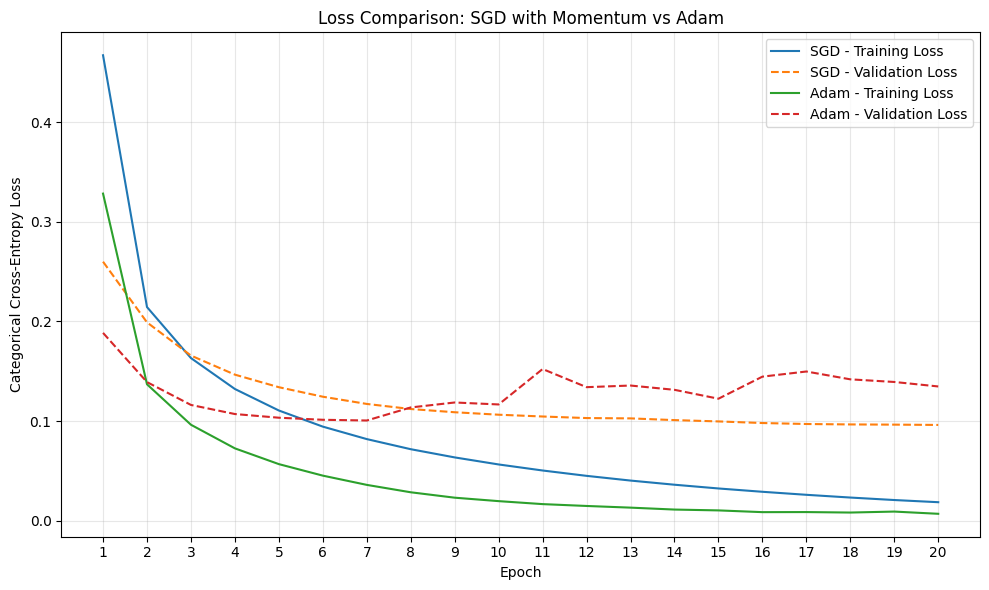

In [31]:
p3_epochs = np.arange(1, P3_EPOCHS + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    p3_epochs,
    sgd_history.history["loss"],
    label="SGD - Training Loss"
)

plt.plot(
    p3_epochs,
    sgd_history.history["val_loss"],
    linestyle="--",
    label="SGD - Validation Loss"
)

plt.plot(
    p3_epochs,
    adam_history.history["loss"],
    label="Adam - Training Loss"
)

plt.plot(
    p3_epochs,
    adam_history.history["val_loss"],
    linestyle="--",
    label="Adam - Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("Loss Comparison: SGD with Momentum vs Adam")
plt.xticks(p3_epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

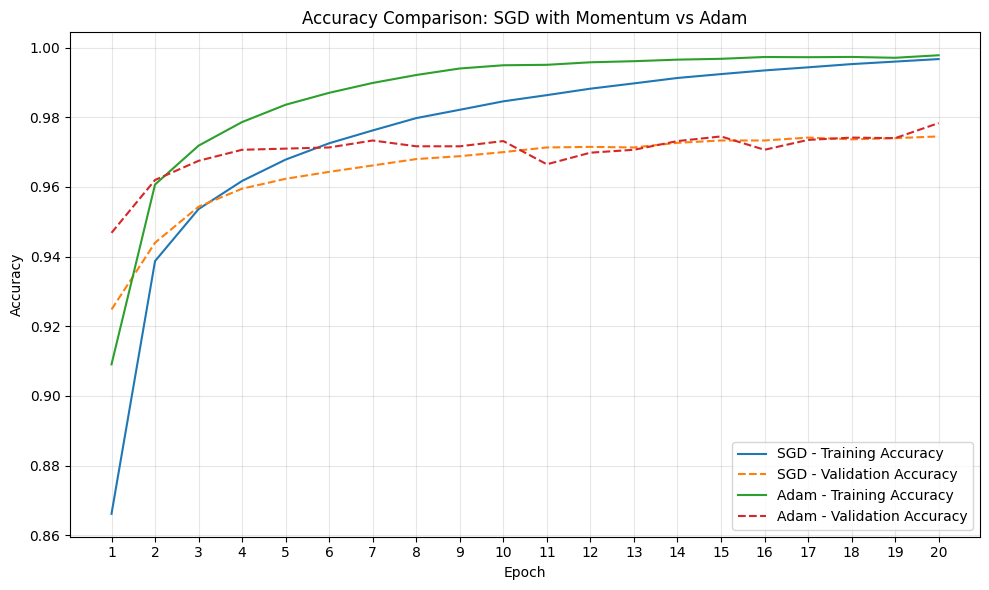

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    p3_epochs,
    sgd_history.history["accuracy"],
    label="SGD - Training Accuracy"
)

plt.plot(
    p3_epochs,
    sgd_history.history["val_accuracy"],
    linestyle="--",
    label="SGD - Validation Accuracy"
)

plt.plot(
    p3_epochs,
    adam_history.history["accuracy"],
    label="Adam - Training Accuracy"
)

plt.plot(
    p3_epochs,
    adam_history.history["val_accuracy"],
    linestyle="--",
    label="Adam - Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison: SGD with Momentum vs Adam")
plt.xticks(p3_epochs)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
def first_epoch_reaching_accuracy(history, threshold=0.97):
    """Return the first epoch reaching a validation-accuracy threshold."""

    val_accuracy = np.asarray(
        history.history["val_accuracy"]
    )

    reached_epochs = np.flatnonzero(
        val_accuracy >= threshold
    )

    if len(reached_epochs) == 0:
        return np.nan

    return int(reached_epochs[0] + 1)


sgd_epoch_97 = first_epoch_reaching_accuracy(
    sgd_history
)

adam_epoch_97 = first_epoch_reaching_accuracy(
    adam_history
)

sgd_stability = float(
    np.std(sgd_history.history["val_loss"][-5:])
)

adam_stability = float(
    np.std(adam_history.history["val_loss"][-5:])
)

p3_diagnostics = pd.DataFrame({
    "Optimizer": ["SGD + Momentum", "Adam"],
    "Epoch Reaching 97% Validation Accuracy": [
        sgd_epoch_97,
        adam_epoch_97
    ],
    "Last-5 Validation Loss Std": [
        sgd_stability,
        adam_stability
    ]
})

display(p3_diagnostics.round(6))

,Optimizer,Epoch Reaching 97% Validation Accuracy,Last-5 Validation Loss Std
0,SGD + Momentum,10,0.000667
1,Adam,4,0.005041


In [34]:
more_accurate_optimizer = p3_optimizer_comparison.loc[
    p3_optimizer_comparison["Test Accuracy"].idxmax(),
    "Optimizer"
]

lower_test_loss_optimizer = p3_optimizer_comparison.loc[
    p3_optimizer_comparison["Test Loss"].idxmin(),
    "Optimizer"
]

shorter_training_optimizer = p3_optimizer_comparison.loc[
    p3_optimizer_comparison["Training Time (s)"].idxmin(),
    "Optimizer"
]

more_stable_optimizer = p3_diagnostics.loc[
    p3_diagnostics["Last-5 Validation Loss Std"].idxmin(),
    "Optimizer"
]

test_accuracy_gap = abs(
    adam_test_results["accuracy"]
    - sgd_test_results["accuracy"]
) * 100

print("Optimizer Comparison Summary")
print("-" * 80)
print(f"Higher test accuracy is:       {more_accurate_optimizer}")
print(f"Lower test loss is:            {lower_test_loss_optimizer}")
print(f"Shorter measured time is:      {shorter_training_optimizer}")
print(f"More stable final behavior is: {more_stable_optimizer}")
print(f"Test accuracy difference is:   {test_accuracy_gap:.2f} percentage points")
print()
print(f"SGD test accuracy is:          {sgd_test_results['accuracy'] * 100:.2f}%")
print(f"Adam test accuracy is:         {adam_test_results['accuracy'] * 100:.2f}%")

Optimizer Comparison Summary
--------------------------------------------------------------------------------
Higher test accuracy is:       Adam
Lower test loss is:            SGD + Momentum
Shorter measured time is:      SGD + Momentum
More stable final behavior is: SGD + Momentum
Test accuracy difference is:   0.18 percentage points

SGD test accuracy is:          97.61%
Adam test accuracy is:         97.79%


# 📌 Part 2 – Optimization for Training Deep Networks

### **1️⃣ Data Preparation**

* The MNIST dataset was divided into:
  * **54,000 training samples**
  * **6,000 validation samples**
  * **10,000 test samples**
* Each \(28\times28\) image was flattened into a vector of size **784**
* Pixel values were normalized from \([0,255]\) to \([0,1]\)
* Class labels were converted into **10-dimensional one-hot vectors**
* The normalized pixel values were verified to remain between **0.0** and **1.0**

### **2️⃣ MLP Architecture**

* The classifier followed the architecture `784 → 128 → 64 → 10`
* Both hidden layers used **ReLU activation**
* The output layer used **softmax activation** for 10-class classification
* The model contained **109,386 trainable parameters**
* Two identical instances of this architecture were trained using:
  * **SGD:** learning rate \(0.01\) and momentum \(0.9\)
  * **Adam:** default learning rate

### **3️⃣ SGD with Momentum**

* SGD completed all **20 epochs**
* Total training time was **21.53 seconds**
* The highest validation accuracy was obtained at epoch **20**
* Final training accuracy was **99.67%**
* Final validation accuracy was **97.45%**
* Final test accuracy was **97.61%**
* Final test loss was **0.0815**

SGD showed gradual and smooth convergence. Its validation loss remained relatively stable near the end of training, with a last-five-epoch standard deviation of only **0.000667**.

### **4️⃣ Adam**

* Adam completed all **20 epochs**
* Total training time was **33.05 seconds**
* The highest validation accuracy was obtained at epoch **20**
* Final training accuracy was **99.78%**
* Final validation accuracy was **97.83%**
* Final test accuracy was **97.79%**
* Final test loss was **0.1016**

Adam converged substantially faster during the initial epochs and reached **97% validation accuracy at epoch 4**, while SGD reached the same threshold at epoch **10**.

However, Adam's validation loss showed greater fluctuations near the end of training, with a last-five-epoch standard deviation of **0.005041**.

### **5️⃣ Convergence and Stability Comparison**

* **Adam** achieved faster initial convergence
* Adam obtained the highest test accuracy, exceeding SGD by **0.18 percentage points**
* **SGD with Momentum** achieved the lower test loss
* SGD required less measured training time
* SGD exhibited more stable validation-loss behavior during the final epochs
* Adam achieved lower training loss but a larger gap between training and validation loss

The increasing and fluctuating validation loss of Adam, despite its continuously decreasing training loss, suggests stronger overfitting during the later epochs. In contrast, SGD converged more slowly but produced smoother and more stable validation behavior.

### **6️⃣ Final Comparison**

| Optimizer | Training Time | Test Loss | Test Accuracy | Epoch Reaching 97% Validation Accuracy |
|---|---:|---:|---:|---:|
| SGD + Momentum | 21.53 s | **0.0815** | 97.61% | 10 |
| Adam | 33.05 s | 0.1016 | **97.79%** | **4** |

> 💡 **Takeaway:**  
> Adam is preferable when rapid initial convergence is the main priority, as it reached high validation accuracy much earlier and achieved the highest final test accuracy. However, the improvement was small—only **0.18 percentage points**—and came with a longer training time, higher test loss, and less stable validation behavior. SGD with Momentum therefore provided the better overall balance of computational efficiency, stability, and generalization, while Adam provided slightly higher classification accuracy.

<div class="alert alert-danger" role="alert"> 
🔎 Part 3: CNN vs. LSTM on Benchmark Datasets

# CNN on CIFAR-10

## Data Preparation

The CIFAR-10 dataset contains 60,000 RGB images of size $32 \times 32$,
distributed across 10 mutually exclusive classes:

$$
\text{airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck}.
$$

The original dataset is divided into 50,000 training images and 10,000
test images. Ten percent of the original training data is reserved as a
fixed stratified validation set.

The preprocessing steps are:

1. Convert pixel values to `float32`.
2. Normalize pixel intensities from $[0,255]$ to $[0,1]$.
3. Convert integer labels to 10-dimensional one-hot vectors.
4. Preserve integer labels for the confusion matrix and error analysis.

* **1.3 Experiment 1: CNN on CIFAR-10**

* **a. Data Preparation**

In [35]:
P4_CNN_SEED = 42
P4_CNN_NUM_CLASSES = 10
P4_CNN_INPUT_SHAPE = (32, 32, 3)

CIFAR10_URL = (
    "https://huggingface.co/datasets/VerisimilitudeX/cifar10/"
    "resolve/main/cifar-10-python.tar.gz?download=true"
)

CIFAR10_MD5 = "c58f30108f718f92721af3b95e74349a"

P4_CNN_CLASS_NAMES = np.array([
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
])

random.seed(P4_CNN_SEED)
np.random.seed(P4_CNN_SEED)
tf.keras.utils.set_random_seed(P4_CNN_SEED)

# Download once and cache locally
cifar10_archive_path = tf.keras.utils.get_file(
    fname="cifar-10-python.tar.gz",
    origin=CIFAR10_URL,
    file_hash=CIFAR10_MD5,
    hash_algorithm="md5",
    cache_subdir="datasets"
)

print("Dataset archive is ready:")
print(cifar10_archive_path)

Dataset archive is ready:
C:\Users\7_Laptop\.keras\datasets\cifar-10-python.tar.gz


In [36]:
def load_cifar_batch(archive, member_name):
    """Load one CIFAR-10 batch from the compressed archive."""
    member = archive.getmember(member_name)

    with archive.extractfile(member) as file:
        return pickle.load(file, encoding="bytes")


with tarfile.open(cifar10_archive_path, mode="r:gz") as archive:
    training_batches = [
        load_cifar_batch(
            archive,
            f"cifar-10-batches-py/data_batch_{batch_number}"
        )
        for batch_number in range(1, 6)
    ]

    test_batch = load_cifar_batch(
        archive,
        "cifar-10-batches-py/test_batch"
    )


X4_cnn_train_full = np.concatenate(
    [batch[b"data"] for batch in training_batches],
    axis=0
)

y4_cnn_train_full_int = np.concatenate(
    [
        np.asarray(batch[b"labels"], dtype=np.int64)
        for batch in training_batches
    ],
    axis=0
)

X4_cnn_test = np.asarray(
    test_batch[b"data"],
    dtype=np.uint8
)

y4_cnn_test_int = np.asarray(
    test_batch[b"labels"],
    dtype=np.int64
)

# Convert flattened channel-first data to RGB images
X4_cnn_train_full = (
    X4_cnn_train_full
    .reshape(-1, 3, 32, 32)
    .transpose(0, 2, 3, 1)
)

X4_cnn_test = (
    X4_cnn_test
    .reshape(-1, 3, 32, 32)
    .transpose(0, 2, 3, 1)
)

assert X4_cnn_train_full.shape == (50000, 32, 32, 3)
assert y4_cnn_train_full_int.shape == (50000,)
assert X4_cnn_test.shape == (10000, 32, 32, 3)
assert y4_cnn_test_int.shape == (10000,)

print("CIFAR-10 loaded successfully.")
print("-" * 60)
print(f"Training images shape is: {X4_cnn_train_full.shape}")
print(f"Training labels shape is: {y4_cnn_train_full_int.shape}")
print(f"Test images shape is:     {X4_cnn_test.shape}")
print(f"Test labels shape is:     {y4_cnn_test_int.shape}")

CIFAR-10 loaded successfully.
------------------------------------------------------------
Training images shape is: (50000, 32, 32, 3)
Training labels shape is: (50000,)
Test images shape is:     (10000, 32, 32, 3)
Test labels shape is:     (10000,)


In [37]:
(
    X4_cnn_train,
    X4_cnn_val,
    y4_cnn_train_int,
    y4_cnn_val_int
) = train_test_split(
    X4_cnn_train_full,
    y4_cnn_train_full_int,
    test_size=0.10,
    random_state=P4_CNN_SEED,
    shuffle=True,
    stratify=y4_cnn_train_full_int
)

# Release the original full training arrays
del X4_cnn_train_full, y4_cnn_train_full_int

# Normalize pixel values to [0, 1]
X4_cnn_train = X4_cnn_train.astype(np.float32) / 255.0
X4_cnn_val = X4_cnn_val.astype(np.float32) / 255.0
X4_cnn_test = X4_cnn_test.astype(np.float32) / 255.0

# One-hot encode labels
y4_cnn_train = tf.keras.utils.to_categorical(
    y4_cnn_train_int,
    num_classes=P4_CNN_NUM_CLASSES
).astype(np.float32)

y4_cnn_val = tf.keras.utils.to_categorical(
    y4_cnn_val_int,
    num_classes=P4_CNN_NUM_CLASSES
).astype(np.float32)

y4_cnn_test = tf.keras.utils.to_categorical(
    y4_cnn_test_int,
    num_classes=P4_CNN_NUM_CLASSES
).astype(np.float32)

In [38]:
assert X4_cnn_train.shape == (45000, 32, 32, 3)
assert X4_cnn_val.shape == (5000, 32, 32, 3)
assert X4_cnn_test.shape == (10000, 32, 32, 3)

assert y4_cnn_train.shape == (45000, 10)
assert y4_cnn_val.shape == (5000, 10)
assert y4_cnn_test.shape == (10000, 10)

assert X4_cnn_train.dtype == np.float32
assert X4_cnn_val.dtype == np.float32
assert X4_cnn_test.dtype == np.float32

assert 0.0 <= X4_cnn_train.min() <= X4_cnn_train.max() <= 1.0
assert 0.0 <= X4_cnn_val.min() <= X4_cnn_val.max() <= 1.0
assert 0.0 <= X4_cnn_test.min() <= X4_cnn_test.max() <= 1.0

assert np.allclose(y4_cnn_train.sum(axis=1), 1.0)
assert np.allclose(y4_cnn_val.sum(axis=1), 1.0)
assert np.allclose(y4_cnn_test.sum(axis=1), 1.0)

p4_cnn_data_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Samples": [
        len(X4_cnn_train),
        len(X4_cnn_val),
        len(X4_cnn_test)
    ],
    "Image Shape": [
        str(X4_cnn_train.shape[1:]),
        str(X4_cnn_val.shape[1:]),
        str(X4_cnn_test.shape[1:])
    ],
    "Label Shape": [
        str(y4_cnn_train.shape[1:]),
        str(y4_cnn_val.shape[1:]),
        str(y4_cnn_test.shape[1:])
    ]
})

display(p4_cnn_data_summary)

print(f"Minimum pixel value is: {X4_cnn_train.min():.1f}")
print(f"Maximum pixel value is: {X4_cnn_train.max():.1f}")

,Dataset,Samples,Image Shape,Label Shape
0,Training,45000,"(32, 32, 3)","(10,)"
1,Validation,5000,"(32, 32, 3)","(10,)"
2,Test,10000,"(32, 32, 3)","(10,)"


Minimum pixel value is: 0.0
Maximum pixel value is: 1.0


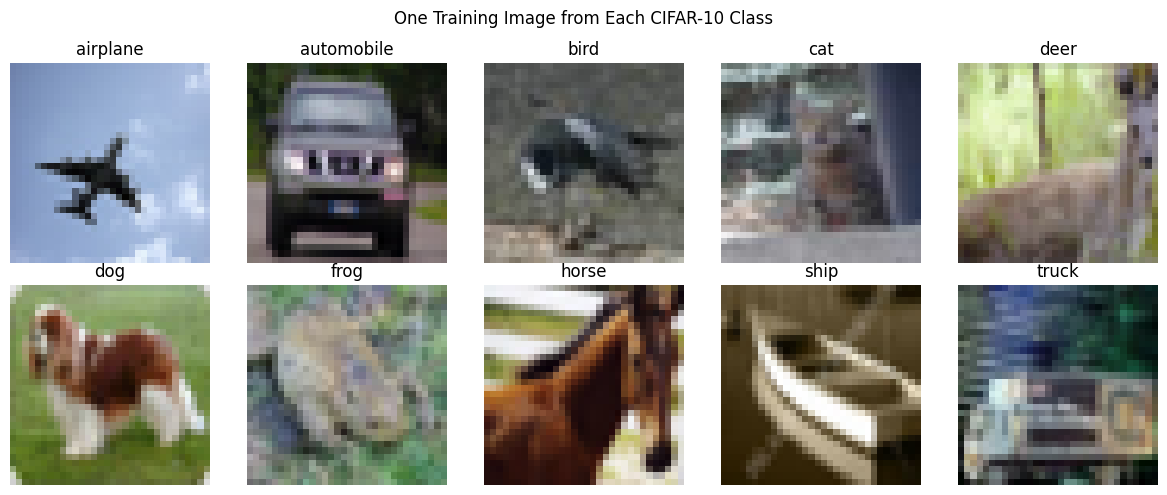

In [39]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_index, ax in enumerate(axes.ravel()):
    sample_index = np.flatnonzero(
        y4_cnn_train_int == class_index
    )[0]

    ax.imshow(X4_cnn_train[sample_index])
    ax.set_title(P4_CNN_CLASS_NAMES[class_index])
    ax.axis("off")

plt.suptitle("One Training Image from Each CIFAR-10 Class")
plt.tight_layout()
plt.show()

* **b. Model Architecture**

In [40]:
P4_CNN_USE_AUGMENTATION = True


def build_cifar10_cnn(
    use_augmentation=P4_CNN_USE_AUGMENTATION,
    seed=P4_CNN_SEED
):
    """Build and compile the required CIFAR-10 CNN."""

    tf.keras.utils.set_random_seed(seed)

    inputs = tf.keras.layers.Input(
        shape=P4_CNN_INPUT_SHAPE,
        name="input"
    )

    x = inputs

    if use_augmentation:
        augmentation = tf.keras.Sequential(
            [
                tf.keras.layers.RandomFlip(
                    mode="horizontal",
                    seed=seed
                ),
                tf.keras.layers.RandomTranslation(
                    height_factor=0.10,
                    width_factor=0.10,
                    fill_mode="reflect",
                    seed=seed + 1
                )
            ],
            name="data_augmentation"
        )

        x = augmentation(x)

    x = tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="valid",
        activation="relu",
        name="conv_1"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="valid",
        activation="relu",
        name="conv_2"
    )(x)

    x = tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2),
        name="max_pool"
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.25,
        name="dropout_conv"
    )(x)

    x = tf.keras.layers.Flatten(
        name="flatten"
    )(x)

    x = tf.keras.layers.Dense(
        units=512,
        activation="relu",
        name="dense_512"
    )(x)

    x = tf.keras.layers.Dropout(
        rate=0.50,
        name="dropout_dense"
    )(x)

    outputs = tf.keras.layers.Dense(
        units=P4_CNN_NUM_CLASSES,
        activation="softmax",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="cifar10_cnn"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.CategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model

In [41]:
tf.keras.backend.clear_session()

cnn_model = build_cifar10_cnn(
    use_augmentation=P4_CNN_USE_AUGMENTATION,
    seed=P4_CNN_SEED
)

conv_layers = [
    layer for layer in cnn_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

pooling_layers = [
    layer for layer in cnn_model.layers
    if isinstance(layer, tf.keras.layers.MaxPooling2D)
]

dropout_layers = [
    layer for layer in cnn_model.layers
    if isinstance(layer, tf.keras.layers.Dropout)
]

dense_layers = [
    layer for layer in cnn_model.layers
    if isinstance(layer, tf.keras.layers.Dense)
]

assert cnn_model.input_shape == (None, 32, 32, 3)
assert cnn_model.output_shape == (None, 10)

assert [layer.filters for layer in conv_layers] == [32, 64]
assert [layer.kernel_size for layer in conv_layers] == [(3, 3), (3, 3)]
assert [layer.activation.__name__ for layer in conv_layers] == [
    "relu",
    "relu"
]

assert len(pooling_layers) == 1
assert pooling_layers[0].pool_size == (2, 2)

assert len(dropout_layers) == 2
assert np.isclose(dropout_layers[0].rate, 0.25)
assert np.isclose(dropout_layers[1].rate, 0.50)

assert [layer.units for layer in dense_layers] == [512, 10]
assert dense_layers[0].activation.__name__ == "relu"
assert dense_layers[1].activation.__name__ == "softmax"

assert cnn_model.count_params() == 6_447_562

cnn_model.summary()

print("\nCNN Configuration")
print("-" * 60)
print(f"Data augmentation is: {P4_CNN_USE_AUGMENTATION}")
print(f"Loss function is:     {cnn_model.loss.name}")
print(f"Optimizer is:         {cnn_model.optimizer.__class__.__name__}")
print(
    "Learning rate is:    "
    f"{float(tf.keras.backend.get_value(cnn_model.optimizer.learning_rate)):.4f}"
)
print(f"Model parameters are: {cnn_model.count_params():,}")

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool (MaxPooling2D)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv (Dropout)          │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,562 (24.60 MB)

 Trainable params: 6,447,562 (24.60 MB)

 Non-trainable params: 0 (0.00 B)


CNN Configuration
------------------------------------------------------------
Data augmentation is: True
Loss function is:     categorical_crossentropy
Optimizer is:         Adam
Learning rate is:    0.0010
Model parameters are: 6,447,562


* **c. Training**

In [42]:
P4_CNN_EPOCHS = 50
P4_CNN_BATCH_SIZE = 64

print(
    "Available GPU devices:",
    tf.config.list_physical_devices("GPU")
)

start_time = time.perf_counter()

cnn_history = cnn_model.fit(
    X4_cnn_train,
    y4_cnn_train,
    validation_data=(X4_cnn_val, y4_cnn_val),
    epochs=P4_CNN_EPOCHS,
    batch_size=P4_CNN_BATCH_SIZE,
    shuffle=True,
    verbose=1
)

cnn_training_time = time.perf_counter() - start_time

assert len(cnn_history.history["loss"]) == P4_CNN_EPOCHS
assert len(cnn_history.history["val_loss"]) == P4_CNN_EPOCHS
assert len(cnn_history.history["accuracy"]) == P4_CNN_EPOCHS
assert len(cnn_history.history["val_accuracy"]) == P4_CNN_EPOCHS

print("\nCNN Training Summary")
print("-" * 60)
print(f"Completed epochs are: {len(cnn_history.history['loss'])}")
print(f"Training time is:     {cnn_training_time:.2f} seconds")

Available GPU devices: []
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 106ms/step - accuracy: 0.4486 - loss: 1.5261 - val_accuracy: 0.5892 - val_loss: 1.1317
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.5653 - loss: 1.2261 - val_accuracy: 0.6336 - val_loss: 1.0194
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 113ms/step - accuracy: 0.5988 - loss: 1.1365 - val_accuracy: 0.6594 - val_loss: 0.9531
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 134ms/step - accuracy: 0.6193 - loss: 1.0750 - val_accuracy: 0.6888 - val_loss: 0.8892
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 226ms/step - accuracy: 0.6352 - loss: 1.0325 - val_accuracy: 0.6984 - val_loss: 0.8595
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 217ms/step - accuracy: 0.6494 - loss: 0.9978 - val_accuracy: 0.7138 - val_loss: 0.8179
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 119s 169ms/step - accuracy: 0.6563 - loss: 0.9726 - val_accuracy: 0.7148 - val_loss: 0.8109
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 107ms/step

In [43]:
cnn_history_df = pd.DataFrame(
    cnn_history.history
)

cnn_history_df.index += 1
cnn_history_df.index.name = "Epoch"

display(cnn_history_df.tail())

,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
46,0.755911,0.701970,0.7806,0.654176
47,0.763089,0.687281,0.7824,0.623106
48,0.760911,0.688807,0.7908,0.608661
49,0.761644,0.685499,0.7774,0.641412
50,0.763422,0.682268,0.7822,0.634205


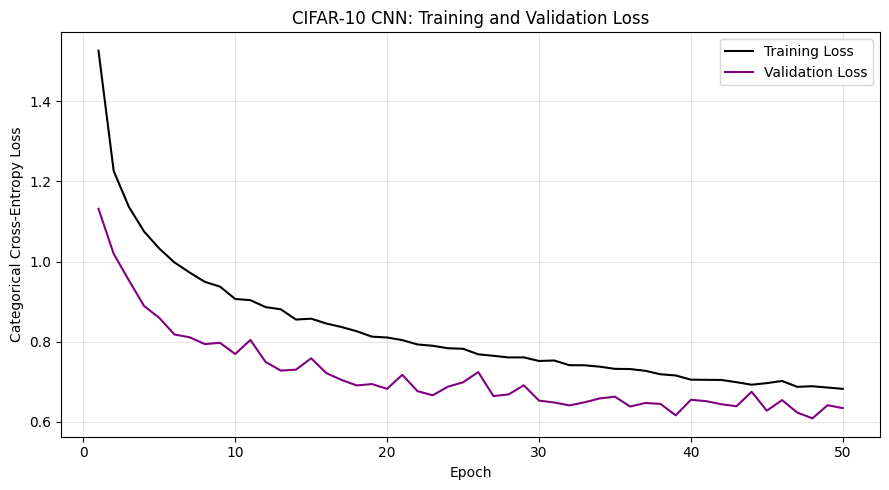

In [44]:
plt.figure(figsize=(9, 5))

plt.plot(
    cnn_history_df.index,
    cnn_history_df["loss"],
    label="Training Loss",
    color='k'
)

plt.plot(
    cnn_history_df.index,
    cnn_history_df["val_loss"],
    label="Validation Loss",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Categorical Cross-Entropy Loss")
plt.title("CIFAR-10 CNN: Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

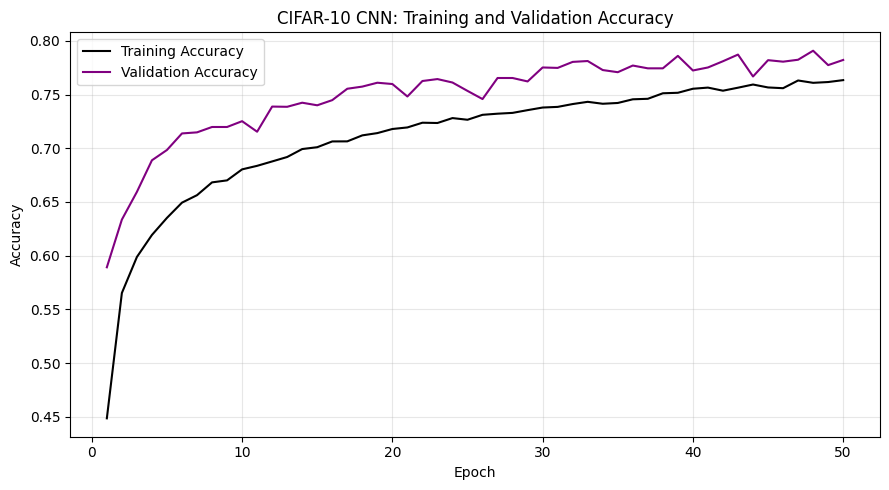

In [45]:
plt.figure(figsize=(9, 5))

plt.plot(
    cnn_history_df.index,
    cnn_history_df["accuracy"],
    label="Training Accuracy",
    color='k'
)

plt.plot(
    cnn_history_df.index,
    cnn_history_df["val_accuracy"],
    label="Validation Accuracy",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CIFAR-10 CNN: Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
cnn_test_results = cnn_model.evaluate(
    X4_cnn_test,
    y4_cnn_test,
    batch_size=P4_CNN_BATCH_SIZE,
    verbose=0,
    return_dict=True
)

cnn_test_probabilities = cnn_model.predict(
    X4_cnn_test,
    batch_size=P4_CNN_BATCH_SIZE,
    verbose=0
)

cnn_test_predictions = np.argmax(
    cnn_test_probabilities,
    axis=1
)

cnn_test_accuracy = accuracy_score(
    y4_cnn_test_int,
    cnn_test_predictions
)

assert cnn_test_probabilities.shape == (10000, 10)

assert np.allclose(
    cnn_test_probabilities.sum(axis=1),
    1.0,
    atol=1e-5
)

assert np.isclose(
    cnn_test_accuracy,
    cnn_test_results["accuracy"],
    atol=1e-6
)

cnn_best_val_loss_epoch = int(
    np.argmin(cnn_history.history["val_loss"]) + 1
)

cnn_best_val_accuracy_epoch = int(
    np.argmax(cnn_history.history["val_accuracy"]) + 1
)

print("CNN Test Results")
print("-" * 60)
print(f"Test loss is:                    {cnn_test_results['loss']:.4f}")
print(f"Test accuracy is:                {cnn_test_accuracy * 100:.2f}%")
print(f"Best validation-loss epoch is:   {cnn_best_val_loss_epoch}")
print(f"Best validation-accuracy epoch is: {cnn_best_val_accuracy_epoch}")

CNN Test Results
------------------------------------------------------------
Test loss is:                    0.6580
Test accuracy is:                78.14%
Best validation-loss epoch is:   48
Best validation-accuracy epoch is: 48


In [47]:
cnn_classification_report = classification_report(
    y4_cnn_test_int,
    cnn_test_predictions,
    target_names=P4_CNN_CLASS_NAMES,
    digits=4,
    output_dict=True
)

cnn_classification_report_df = pd.DataFrame(
    cnn_classification_report
).T

display(cnn_classification_report_df.round(4))

,precision,recall,f1-score,support
airplane,0.8083,0.8220,0.8151,1000.0000
automobile,0.8870,0.9030,0.8949,1000.0000
bird,0.8518,0.5690,0.6823,1000.0000
cat,0.6620,0.5700,0.6126,1000.0000
deer,0.8096,0.6720,0.7344,1000.0000
dog,0.7019,0.7180,0.7098,1000.0000
frog,0.6739,0.9340,0.7829,1000.0000
horse,0.7853,0.8560,0.8191,1000.0000
ship,0.8945,0.8480,0.8706,1000.0000
truck,0.7955,0.9220,0.8541,1000.0000


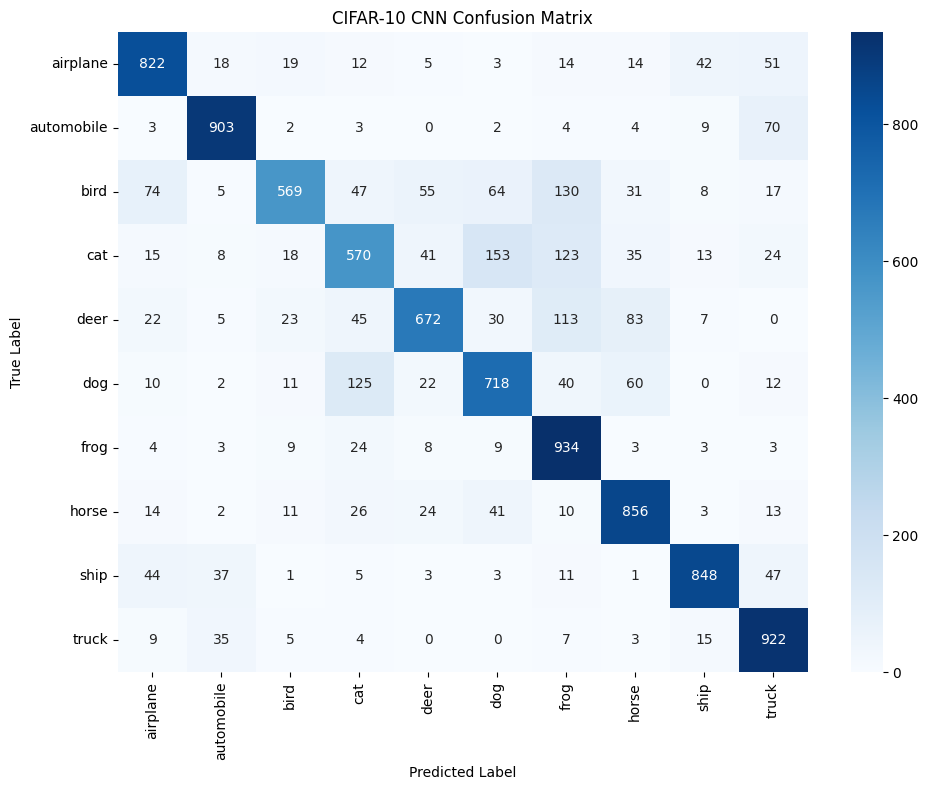

In [48]:
cnn_confusion_matrix = confusion_matrix(
    y4_cnn_test_int,
    cnn_test_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cnn_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=P4_CNN_CLASS_NAMES,
    yticklabels=P4_CNN_CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [49]:
cnn_fpr = {}
cnn_tpr = {}
cnn_roc_auc = {}

for class_index in range(P4_CNN_NUM_CLASSES):
    cnn_fpr[class_index], cnn_tpr[class_index], _ = roc_curve(
        y4_cnn_test[:, class_index],
        cnn_test_probabilities[:, class_index]
    )

    cnn_roc_auc[class_index] = auc(
        cnn_fpr[class_index],
        cnn_tpr[class_index]
    )

# Micro-average ROC
cnn_fpr["micro"], cnn_tpr["micro"], _ = roc_curve(
    y4_cnn_test.ravel(),
    cnn_test_probabilities.ravel()
)

cnn_roc_auc["micro"] = auc(
    cnn_fpr["micro"],
    cnn_tpr["micro"]
)

# Macro-average ROC
all_fpr = np.unique(
    np.concatenate([
        cnn_fpr[class_index]
        for class_index in range(P4_CNN_NUM_CLASSES)
    ])
)

mean_tpr = np.zeros_like(all_fpr)

for class_index in range(P4_CNN_NUM_CLASSES):
    mean_tpr += np.interp(
        all_fpr,
        cnn_fpr[class_index],
        cnn_tpr[class_index]
    )

mean_tpr /= P4_CNN_NUM_CLASSES

cnn_fpr["macro"] = all_fpr
cnn_tpr["macro"] = mean_tpr

cnn_roc_auc["macro"] = auc(
    cnn_fpr["macro"],
    cnn_tpr["macro"]
)

In [50]:
cnn_class_auc_df = pd.DataFrame({
    "Class": P4_CNN_CLASS_NAMES,
    "OvR ROC-AUC": [
        cnn_roc_auc[class_index]
        for class_index in range(P4_CNN_NUM_CLASSES)
    ]
}).sort_values(
    by="OvR ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(cnn_class_auc_df.round(4))

print(f"Micro-average ROC-AUC is: {cnn_roc_auc['micro']:.4f}")
print(f"Macro-average ROC-AUC is: {cnn_roc_auc['macro']:.4f}")

,Class,OvR ROC-AUC
0,automobile,0.9933
1,ship,0.9912
2,truck,0.9907
3,frog,0.9864
4,horse,0.9847
5,airplane,0.9803
6,deer,0.9720
7,dog,0.9638
8,bird,0.9516
9,cat,0.9390


Micro-average ROC-AUC is: 0.9766
Macro-average ROC-AUC is: 0.9754


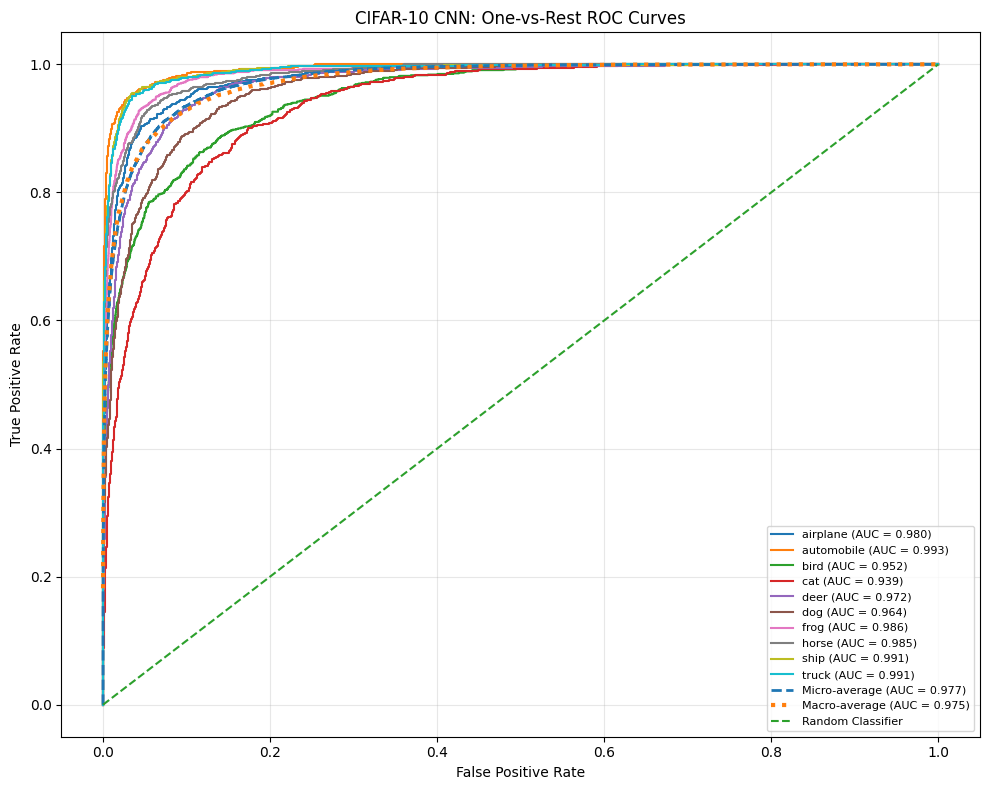

In [51]:
plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(P4_CNN_CLASS_NAMES):
    plt.plot(
        cnn_fpr[class_index],
        cnn_tpr[class_index],
        label=(
            f"{class_name} "
            f"(AUC = {cnn_roc_auc[class_index]:.3f})"
        )
    )

plt.plot(
    cnn_fpr["micro"],
    cnn_tpr["micro"],
    linestyle="--",
    linewidth=2,
    label=f"Micro-average (AUC = {cnn_roc_auc['micro']:.3f})"
)

plt.plot(
    cnn_fpr["macro"],
    cnn_tpr["macro"],
    linestyle=":",
    linewidth=3,
    label=f"Macro-average (AUC = {cnn_roc_auc['macro']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CIFAR-10 CNN: One-vs-Rest ROC Curves")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Number of misclassified test images is: 2186


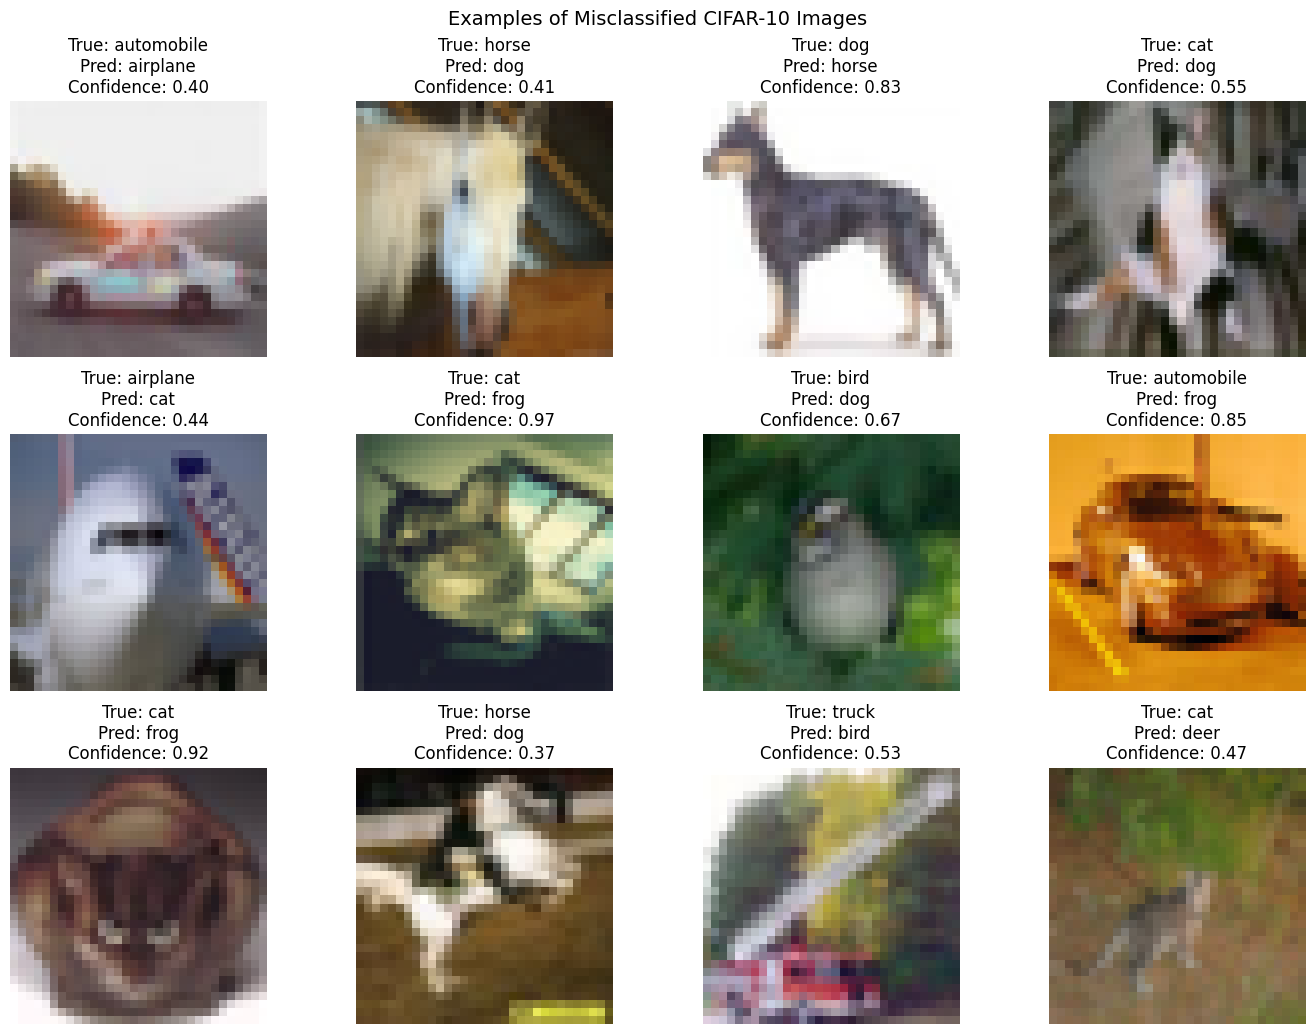

In [52]:
cnn_misclassified_indices = np.flatnonzero(
    cnn_test_predictions != y4_cnn_test_int
)

P4_CNN_NUM_MISCLASSIFIED = min(
    12,
    len(cnn_misclassified_indices)
)

print(
    "Number of misclassified test images is:",
    len(cnn_misclassified_indices)
)

if P4_CNN_NUM_MISCLASSIFIED > 0:
    rng = np.random.default_rng(P4_CNN_SEED)

    selected_indices = rng.choice(
        cnn_misclassified_indices,
        size=P4_CNN_NUM_MISCLASSIFIED,
        replace=False
    )

    n_columns = 4
    n_rows = int(
        np.ceil(P4_CNN_NUM_MISCLASSIFIED / n_columns)
    )

    fig, axes = plt.subplots(
        n_rows,
        n_columns,
        figsize=(14, 3.5 * n_rows)
    )

    axes = np.atleast_1d(axes).ravel()

    for ax, sample_index in zip(
        axes,
        selected_indices
    ):
        true_class = y4_cnn_test_int[sample_index]
        predicted_class = cnn_test_predictions[sample_index]

        predicted_confidence = cnn_test_probabilities[
            sample_index,
            predicted_class
        ]

        ax.imshow(X4_cnn_test[sample_index])

        ax.set_title(
            f"True: {P4_CNN_CLASS_NAMES[true_class]}\n"
            f"Pred: {P4_CNN_CLASS_NAMES[predicted_class]}\n"
            f"Confidence: {predicted_confidence:.2f}"
        )

        ax.axis("off")

    for ax in axes[P4_CNN_NUM_MISCLASSIFIED:]:
        ax.axis("off")

    plt.suptitle(
        "Examples of Misclassified CIFAR-10 Images",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [53]:
cnn_final_training_accuracy = float(
    cnn_history.history["accuracy"][-1]
)

cnn_final_validation_accuracy = float(
    cnn_history.history["val_accuracy"][-1]
)

cnn_generalization_gap = (
    cnn_final_training_accuracy
    - cnn_final_validation_accuracy
)

highest_auc_row = cnn_class_auc_df.iloc[0]
lowest_auc_row = cnn_class_auc_df.iloc[-1]

cnn_results_summary = pd.DataFrame({
    "Metric": [
        "Completed Epochs",
        "Training Time (s)",
        "Model Parameters",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Test Loss",
        "Test Accuracy",
        "Micro ROC-AUC",
        "Macro ROC-AUC",
        "Misclassified Images"
    ],
    "Value": [
        P4_CNN_EPOCHS,
        cnn_training_time,
        cnn_model.count_params(),
        cnn_final_training_accuracy,
        cnn_final_validation_accuracy,
        cnn_test_results["loss"],
        cnn_test_accuracy,
        cnn_roc_auc["micro"],
        cnn_roc_auc["macro"],
        len(cnn_misclassified_indices)
    ]
})

display(cnn_results_summary)

print("\nCIFAR-10 CNN Final Summary")
print("-" * 80)
print(f"Completed epochs are:              {P4_CNN_EPOCHS}")
print(f"Training time is:                  {cnn_training_time:.2f} seconds")
print(f"Model parameters are:              {cnn_model.count_params():,}")
print(f"Final training accuracy is:        {cnn_final_training_accuracy * 100:.2f}%")
print(f"Final validation accuracy is:      {cnn_final_validation_accuracy * 100:.2f}%")
print(f"Test accuracy is:                  {cnn_test_accuracy * 100:.2f}%")
print(f"Test loss is:                      {cnn_test_results['loss']:.4f}")
print(f"Train-validation accuracy gap is:  {cnn_generalization_gap * 100:.2f} percentage points")
print(f"Macro one-vs-rest ROC-AUC is:      {cnn_roc_auc['macro']:.4f}")
print(
    "Highest class ROC-AUC is:          "
    f"{highest_auc_row['Class']} "
    f"({highest_auc_row['OvR ROC-AUC']:.4f})"
)
print(
    "Lowest class ROC-AUC is:           "
    f"{lowest_auc_row['Class']} "
    f"({lowest_auc_row['OvR ROC-AUC']:.4f})"
)
print(f"Misclassified test images are:     {len(cnn_misclassified_indices):,}")

,Metric,Value
0,Completed Epochs,5.000000e+01
1,Training Time (s),3.693739e+03
2,Model Parameters,6.447562e+06
3,Final Training Accuracy,7.634223e-01
4,Final Validation Accuracy,7.822000e-01
5,Test Loss,6.579833e-01
6,Test Accuracy,7.814000e-01
7,Micro ROC-AUC,9.766202e-01
8,Macro ROC-AUC,9.754020e-01
9,Misclassified Images,2.186000e+03



CIFAR-10 CNN Final Summary
--------------------------------------------------------------------------------
Completed epochs are:              50
Training time is:                  3693.74 seconds
Model parameters are:              6,447,562
Final training accuracy is:        76.34%
Final validation accuracy is:      78.22%
Test accuracy is:                  78.14%
Test loss is:                      0.6580
Train-validation accuracy gap is:  -1.88 percentage points
Macro one-vs-rest ROC-AUC is:      0.9754
Highest class ROC-AUC is:          automobile (0.9933)
Lowest class ROC-AUC is:           cat (0.9390)
Misclassified test images are:     2,186


* **2.3 Experiment 2: LSTM on IMDB Sentiment**

* **a. Data Preparation**

In [54]:
P4_LSTM_DATA_URL = "https://s3.amazonaws.com/text-datasets/imdb.npz"
P4_LSTM_WORD_INDEX_URL = (
    "https://s3.amazonaws.com/text-datasets/imdb_word_index.json"
)

imdb_data_path = tf.keras.utils.get_file(
    fname="imdb.npz",
    origin=P4_LSTM_DATA_URL,
    cache_subdir="datasets"
)

imdb_word_index_path = tf.keras.utils.get_file(
    fname="imdb_word_index.json",
    origin=P4_LSTM_WORD_INDEX_URL,
    cache_subdir="datasets"
)

print("IMDB files are ready.")
print(imdb_data_path)
print(imdb_word_index_path)

IMDB files are ready.
C:\Users\7_Laptop\.keras\datasets\imdb.npz
C:\Users\7_Laptop\.keras\datasets\imdb_word_index.json


In [55]:
P4_LSTM_SEED = 42
P4_LSTM_VOCAB_SIZE = 20_000
P4_LSTM_SEQUENCE_LENGTH = 200

P4_LSTM_PAD_INDEX = 0
P4_LSTM_START_INDEX = 1
P4_LSTM_UNK_INDEX = 2
P4_LSTM_INDEX_FROM = 3

random.seed(P4_LSTM_SEED)
np.random.seed(P4_LSTM_SEED)
tf.keras.utils.set_random_seed(P4_LSTM_SEED)

(
    (X4_lstm_train_full_raw, y4_lstm_train_full),
    (X4_lstm_test_raw, y4_lstm_test)
) = tf.keras.datasets.imdb.load_data(
    path=Path(imdb_data_path).name,
    num_words=P4_LSTM_VOCAB_SIZE,
    seed=P4_LSTM_SEED,
    start_char=P4_LSTM_START_INDEX,
    oov_char=P4_LSTM_UNK_INDEX,
    index_from=P4_LSTM_INDEX_FROM
)

y4_lstm_train_full = np.asarray(
    y4_lstm_train_full,
    dtype=np.float32
)

y4_lstm_test = np.asarray(
    y4_lstm_test,
    dtype=np.float32
)

print("IMDB dataset loaded successfully.")
print(f"Training reviews are: {len(X4_lstm_train_full_raw):,}")
print(f"Test reviews are:     {len(X4_lstm_test_raw):,}")
print(f"Number of classes is:      {len(np.unique(y4_lstm_train_full))}")

IMDB dataset loaded successfully.
Training reviews are: 25,000
Test reviews are:     25,000
Number of classes is:      2


In [56]:
(
    X4_lstm_train_raw,
    X4_lstm_val_raw,
    y4_lstm_train,
    y4_lstm_val
) = train_test_split(
    X4_lstm_train_full_raw,
    y4_lstm_train_full,
    test_size=0.10,
    random_state=P4_LSTM_SEED,
    shuffle=True,
    stratify=y4_lstm_train_full
)

del X4_lstm_train_full_raw, y4_lstm_train_full

print(f"Training reviews are:   {len(X4_lstm_train_raw):,}")
print(f"Validation reviews are: {len(X4_lstm_val_raw):,}")
print(f"Test reviews are:       {len(X4_lstm_test_raw):,}")

Training reviews are:   22,500
Validation reviews are: 2,500
Test reviews are:       25,000


In [57]:
X4_lstm_train = tf.keras.utils.pad_sequences(
    X4_lstm_train_raw,
    maxlen=P4_LSTM_SEQUENCE_LENGTH,
    dtype="int32",
    padding="pre",
    truncating="post",
    value=P4_LSTM_PAD_INDEX
)

X4_lstm_val = tf.keras.utils.pad_sequences(
    X4_lstm_val_raw,
    maxlen=P4_LSTM_SEQUENCE_LENGTH,
    dtype="int32",
    padding="pre",
    truncating="post",
    value=P4_LSTM_PAD_INDEX
)

X4_lstm_test = tf.keras.utils.pad_sequences(
    X4_lstm_test_raw,
    maxlen=P4_LSTM_SEQUENCE_LENGTH,
    dtype="int32",
    padding="pre",
    truncating="post",
    value=P4_LSTM_PAD_INDEX
)

In [58]:
assert X4_lstm_train.shape == (22500, 200)
assert X4_lstm_val.shape == (2500, 200)
assert X4_lstm_test.shape == (25000, 200)

assert X4_lstm_train.dtype == np.int32
assert X4_lstm_val.dtype == np.int32
assert X4_lstm_test.dtype == np.int32

assert X4_lstm_train.min() >= 0
assert X4_lstm_val.min() >= 0
assert X4_lstm_test.min() >= 0

assert X4_lstm_train.max() < P4_LSTM_VOCAB_SIZE
assert X4_lstm_val.max() < P4_LSTM_VOCAB_SIZE
assert X4_lstm_test.max() < P4_LSTM_VOCAB_SIZE

assert set(np.unique(y4_lstm_train)).issubset({0.0, 1.0})
assert set(np.unique(y4_lstm_val)).issubset({0.0, 1.0})
assert set(np.unique(y4_lstm_test)).issubset({0.0, 1.0})

p4_lstm_data_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Samples": [
        len(X4_lstm_train),
        len(X4_lstm_val),
        len(X4_lstm_test)
    ],
    "Sequence Shape": [
        str(X4_lstm_train.shape[1:]),
        str(X4_lstm_val.shape[1:]),
        str(X4_lstm_test.shape[1:])
    ],
    "Negative Reviews": [
        int(np.sum(y4_lstm_train == 0)),
        int(np.sum(y4_lstm_val == 0)),
        int(np.sum(y4_lstm_test == 0))
    ],
    "Positive Reviews": [
        int(np.sum(y4_lstm_train == 1)),
        int(np.sum(y4_lstm_val == 1)),
        int(np.sum(y4_lstm_test == 1))
    ]
})

display(p4_lstm_data_summary)

print(f"Minimum token index is: {X4_lstm_train.min()}")
print(f"Maximum token index is: {X4_lstm_train.max()}")

,Dataset,Samples,Sequence Shape,Negative Reviews,Positive Reviews
0,Training,22500,"(200,)",11250,11250
1,Validation,2500,"(200,)",1250,1250
2,Test,25000,"(200,)",12500,12500


Minimum token index is: 0
Maximum token index is: 19999


In [59]:
p4_lstm_length_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Mean Original Length": [
        np.mean([len(review) for review in X4_lstm_train_raw]),
        np.mean([len(review) for review in X4_lstm_val_raw]),
        np.mean([len(review) for review in X4_lstm_test_raw])
    ],
    "Median Original Length": [
        np.median([len(review) for review in X4_lstm_train_raw]),
        np.median([len(review) for review in X4_lstm_val_raw]),
        np.median([len(review) for review in X4_lstm_test_raw])
    ],
    "Maximum Original Length": [
        np.max([len(review) for review in X4_lstm_train_raw]),
        np.max([len(review) for review in X4_lstm_val_raw]),
        np.max([len(review) for review in X4_lstm_test_raw])
    ]
})

display(p4_lstm_length_summary.round(2))

,Dataset,Mean Original Length,Median Original Length,Maximum Original Length
0,Training,238.59,178.0,2494
1,Validation,239.80,176.0,1733
2,Test,230.80,174.0,2315


* **b. Model Architecture**

In [60]:
P4_LSTM_EMBEDDING_DIM = 128
P4_LSTM_UNITS = 128
P4_LSTM_DENSE_UNITS = 64
P4_LSTM_DROPOUT_RATE = 0.50


def build_imdb_lstm(seed=P4_LSTM_SEED):
    """Build and compile the required IMDB sentiment classifier."""

    tf.keras.utils.set_random_seed(seed)

    inputs = tf.keras.layers.Input(
        shape=(P4_LSTM_SEQUENCE_LENGTH,),
        dtype="int32",
        name="input"
    )

    x = tf.keras.layers.Embedding(
        input_dim=P4_LSTM_VOCAB_SIZE,
        output_dim=P4_LSTM_EMBEDDING_DIM,
        mask_zero=True,
        name="embedding"
    )(inputs)

    x = tf.keras.layers.LSTM(
        units=P4_LSTM_UNITS,
        return_sequences=False,
        name="lstm"
    )(x)

    x = tf.keras.layers.Dense(
        units=P4_LSTM_DENSE_UNITS,
        activation="relu",
        name="dense_64"
    )(x)

    x = tf.keras.layers.Dropout(
        rate=P4_LSTM_DROPOUT_RATE,
        name="dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        units=1,
        activation="sigmoid",
        name="output"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="imdb_lstm"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy",
                threshold=0.5
            )
        ]
    )

    return model

In [61]:
tf.keras.backend.clear_session()

lstm_model = build_imdb_lstm(
    seed=P4_LSTM_SEED
)

embedding_layers = [
    layer for layer in lstm_model.layers
    if isinstance(layer, tf.keras.layers.Embedding)
]

lstm_layers = [
    layer for layer in lstm_model.layers
    if isinstance(layer, tf.keras.layers.LSTM)
]

dense_layers = [
    layer for layer in lstm_model.layers
    if isinstance(layer, tf.keras.layers.Dense)
]

dropout_layers = [
    layer for layer in lstm_model.layers
    if isinstance(layer, tf.keras.layers.Dropout)
]

assert lstm_model.input_shape == (None, 200)
assert lstm_model.output_shape == (None, 1)

assert len(embedding_layers) == 1
assert embedding_layers[0].input_dim == 20_000
assert embedding_layers[0].output_dim == 128
assert embedding_layers[0].mask_zero is True

assert len(lstm_layers) == 1
assert lstm_layers[0].units == 128
assert lstm_layers[0].return_sequences is False

assert [layer.units for layer in dense_layers] == [64, 1]
assert dense_layers[0].activation.__name__ == "relu"
assert dense_layers[1].activation.__name__ == "sigmoid"

assert len(dropout_layers) == 1
assert np.isclose(dropout_layers[0].rate, 0.50)

assert lstm_model.count_params() == 2_699_905

lstm_model.summary()

print("\nLSTM Configuration")
print("-" * 60)
print(f"Vocabulary size is: {P4_LSTM_VOCAB_SIZE:,}")
print(f"Sequence length is: {P4_LSTM_SEQUENCE_LENGTH}")
print(f"Loss function is:   {lstm_model.loss.name}")
print(f"Optimizer is:       {lstm_model.optimizer.__class__.__name__}")
print(
    "Learning rate is:  "
    f"{float(tf.keras.backend.get_value(lstm_model.optimizer.learning_rate)):.4f}"
)
print(f"Model parameters are: {lstm_model.count_params():,}")

Model: "imdb_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 200, 128)  │  2,560,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │    131,584 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │      8,256 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_64[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)


LSTM Configuration
------------------------------------------------------------
Vocabulary size is: 20,000
Sequence length is: 200
Loss function is:   binary_crossentropy
Optimizer is:       Adam
Learning rate is:  0.0010
Model parameters are: 2,699,905


* **c. Training**

In [62]:
P4_LSTM_EPOCHS = 20
P4_LSTM_BATCH_SIZE = 64

print(
    "Available GPU devices:",
    tf.config.list_physical_devices("GPU")
)

start_time = time.perf_counter()

lstm_history = lstm_model.fit(
    X4_lstm_train,
    y4_lstm_train,
    validation_data=(X4_lstm_val, y4_lstm_val),
    epochs=P4_LSTM_EPOCHS,
    batch_size=P4_LSTM_BATCH_SIZE,
    shuffle=True,
    verbose=1
)

lstm_training_time = time.perf_counter() - start_time

assert len(lstm_history.history["loss"]) == P4_LSTM_EPOCHS
assert len(lstm_history.history["val_loss"]) == P4_LSTM_EPOCHS
assert len(lstm_history.history["accuracy"]) == P4_LSTM_EPOCHS
assert len(lstm_history.history["val_accuracy"]) == P4_LSTM_EPOCHS

print("\nLSTM Training Summary")
print("-" * 60)
print(f"Completed epochs are: {len(lstm_history.history['loss'])}")
print(f"Training time is:     {lstm_training_time:.2f} seconds")

Available GPU devices: []
Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 69s 193ms/step - accuracy: 0.7527 - loss: 0.5170 - val_accuracy: 0.8376 - val_loss: 0.3840
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 191ms/step - accuracy: 0.8925 - loss: 0.2866 - val_accuracy: 0.8668 - val_loss: 0.3506
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 191ms/step - accuracy: 0.9324 - loss: 0.1940 - val_accuracy: 0.8348 - val_loss: 0.4678
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 192ms/step - accuracy: 0.9407 - loss: 0.1680 - val_accuracy: 0.8588 - val_loss: 0.5156
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.9357 - loss: 0.1736 - val_accuracy: 0.8212 - val_loss: 0.5240
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 70s 198ms/step - accuracy: 0.9630 - loss: 0.1066 - val_accuracy: 0.8344 - val_loss: 0.5208
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 190ms/step - accuracy: 0.9782 - loss: 0.0659 - val_accuracy: 0.8292 - val_loss: 0.7546
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 190ms/step - 

In [63]:
lstm_history_df = pd.DataFrame(
    lstm_history.history
)

lstm_history_df.index += 1
lstm_history_df.index.name = "Epoch"

display(lstm_history_df.tail())

,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
16,0.994489,0.018696,0.8188,0.928870
17,0.997911,0.007915,0.8220,1.112515
18,0.997956,0.006271,0.8408,1.176991
19,0.997867,0.007653,0.8168,1.432645
20,0.996933,0.009264,0.8076,1.518990


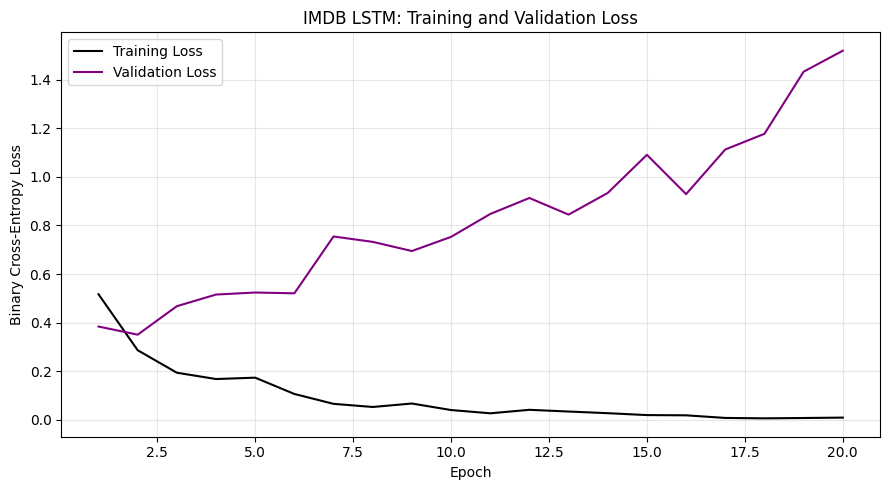

In [64]:
plt.figure(figsize=(9, 5))

plt.plot(
    lstm_history_df.index,
    lstm_history_df["loss"],
    label="Training Loss",
    color='k'
)

plt.plot(
    lstm_history_df.index,
    lstm_history_df["val_loss"],
    label="Validation Loss",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("IMDB LSTM: Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

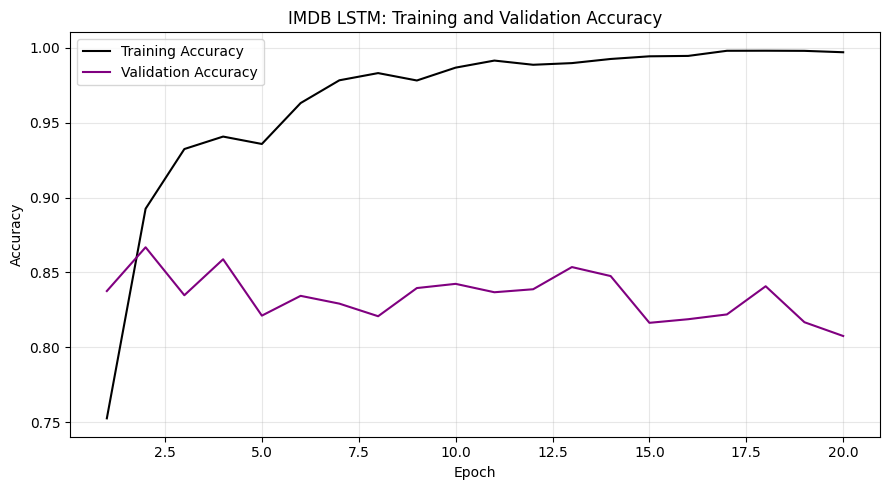

In [65]:
plt.figure(figsize=(9, 5))

plt.plot(
    lstm_history_df.index,
    lstm_history_df["accuracy"],
    label="Training Accuracy",
    color='k'
)

plt.plot(
    lstm_history_df.index,
    lstm_history_df["val_accuracy"],
    label="Validation Accuracy",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("IMDB LSTM: Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* **d. Evaluation**

In [66]:
lstm_test_results = lstm_model.evaluate(
    X4_lstm_test,
    y4_lstm_test,
    batch_size=P4_LSTM_BATCH_SIZE,
    verbose=0,
    return_dict=True
)

lstm_test_probabilities = lstm_model.predict(
    X4_lstm_test,
    batch_size=P4_LSTM_BATCH_SIZE,
    verbose=0
).ravel()

lstm_test_predictions = (
    lstm_test_probabilities >= 0.5
).astype(np.int64)

lstm_test_labels_int = y4_lstm_test.astype(np.int64)

lstm_test_accuracy = accuracy_score(
    lstm_test_labels_int,
    lstm_test_predictions
)

lstm_test_precision = precision_score(
    lstm_test_labels_int,
    lstm_test_predictions,
    zero_division=0
)

lstm_test_recall = recall_score(
    lstm_test_labels_int,
    lstm_test_predictions,
    zero_division=0
)

lstm_test_f1 = f1_score(
    lstm_test_labels_int,
    lstm_test_predictions,
    zero_division=0
)

assert lstm_test_probabilities.shape == (25000,)
assert np.all(
    (lstm_test_probabilities >= 0.0)
    & (lstm_test_probabilities <= 1.0)
)

assert np.isclose(
    lstm_test_accuracy,
    lstm_test_results["accuracy"],
    atol=1e-6
)

lstm_metrics_df = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-Score"
    ],
    "Value": [
        lstm_test_results["loss"],
        lstm_test_accuracy,
        lstm_test_precision,
        lstm_test_recall,
        lstm_test_f1
    ]
})

display(lstm_metrics_df.round(4))

,Metric,Value
0,Test Loss,1.6217
1,Test Accuracy,0.7884
2,Test Precision,0.7363
3,Test Recall,0.8986
4,Test F1-Score,0.8094


In [67]:
print("IMDB LSTM Test Results")
print("-" * 60)
print(f"Test loss is:      {lstm_test_results['loss']:.4f}")
print(f"Test accuracy is:  {lstm_test_accuracy * 100:.2f}%")
print(f"Test precision is: {lstm_test_precision * 100:.2f}%")
print(f"Test recall is:    {lstm_test_recall * 100:.2f}%")
print(f"Test F1-score is:  {lstm_test_f1 * 100:.2f}%")

IMDB LSTM Test Results
------------------------------------------------------------
Test loss is:      1.6217
Test accuracy is:  78.84%
Test precision is: 73.63%
Test recall is:    89.86%
Test F1-score is:  80.94%


In [68]:
lstm_classification_report = classification_report(
    lstm_test_labels_int,
    lstm_test_predictions,
    target_names=["Negative", "Positive"],
    digits=4,
    output_dict=True
)

lstm_classification_report_df = pd.DataFrame(
    lstm_classification_report
).T

display(lstm_classification_report_df.round(4))

,precision,recall,f1-score,support
Negative,0.8700,0.6782,0.7622,12500.0000
Positive,0.7363,0.8986,0.8094,12500.0000
accuracy,0.7884,0.7884,0.7884,0.7884
macro avg,0.8031,0.7884,0.7858,25000.0000
weighted avg,0.8031,0.7884,0.7858,25000.0000


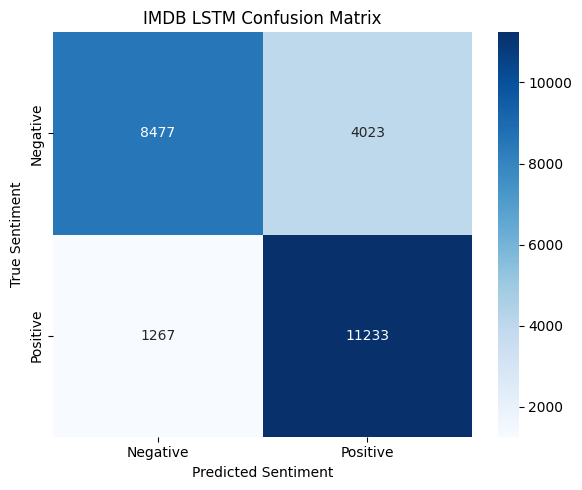

In [69]:
lstm_confusion_matrix = confusion_matrix(
    lstm_test_labels_int,
    lstm_test_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    lstm_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.title("IMDB LSTM Confusion Matrix")
plt.tight_layout()
plt.show()

In [70]:
imdb_word_index = tf.keras.datasets.imdb.get_word_index()

imdb_index_to_word = {
    word_index + P4_LSTM_INDEX_FROM: word
    for word, word_index in imdb_word_index.items()
}

imdb_index_to_word.update({
    P4_LSTM_PAD_INDEX: "<PAD>",
    P4_LSTM_START_INDEX: "<START>",
    P4_LSTM_UNK_INDEX: "<UNK>",
    P4_LSTM_INDEX_FROM: "<UNUSED>"
})


def decode_imdb_review(sequence):
    """Convert a padded integer sequence into readable text."""

    tokens = [
        imdb_index_to_word.get(int(token), "<UNK>")
        for token in sequence
        if token not in {
            P4_LSTM_PAD_INDEX,
            P4_LSTM_START_INDEX
        }
    ]

    return " ".join(tokens)

In [71]:
lstm_false_positive_indices = np.flatnonzero(
    (lstm_test_labels_int == 0)
    & (lstm_test_predictions == 1)
)

lstm_false_negative_indices = np.flatnonzero(
    (lstm_test_labels_int == 1)
    & (lstm_test_predictions == 0)
)


def select_most_confident_errors(indices, count):
    """Select the most confident incorrect predictions."""

    if len(indices) == 0:
        return np.array([], dtype=np.int64)

    error_confidences = np.maximum(
        lstm_test_probabilities[indices],
        1.0 - lstm_test_probabilities[indices]
    )

    ranked_positions = np.argsort(
        error_confidences
    )[::-1]

    return indices[
        ranked_positions[:min(count, len(indices))]
    ]


selected_false_positives = select_most_confident_errors(
    lstm_false_positive_indices,
    count=3
)

selected_false_negatives = select_most_confident_errors(
    lstm_false_negative_indices,
    count=3
)

selected_lstm_errors = np.concatenate([
    selected_false_positives,
    selected_false_negatives
])

print(f"False positives are: {len(lstm_false_positive_indices):,}")
print(f"False negatives are: {len(lstm_false_negative_indices):,}")
print(f"Displayed errors are: {len(selected_lstm_errors)}")

False positives are: 4,023
False negatives are: 1,267
Displayed errors are: 6


In [72]:
P4_LSTM_SENTIMENT_NAMES = np.array([
    "Negative",
    "Positive"
])

for example_number, sample_index in enumerate(
    selected_lstm_errors,
    start=1
):
    true_label = lstm_test_labels_int[sample_index]
    predicted_label = lstm_test_predictions[sample_index]
    positive_probability = lstm_test_probabilities[sample_index]

    decoded_text = decode_imdb_review(
        X4_lstm_test[sample_index]
    )

    print("=" * 100)
    print(f"Misclassified Review {example_number}")
    print("-" * 100)
    print(
        f"True sentiment:      "
        f"{P4_LSTM_SENTIMENT_NAMES[true_label]}"
    )
    print(
        f"Predicted sentiment: "
        f"{P4_LSTM_SENTIMENT_NAMES[predicted_label]}"
    )
    print(
        f"Positive probability: "
        f"{positive_probability:.4f}"
    )
    print("-" * 100)
    print(
        textwrap.fill(
            decoded_text,
            width=100
        )
    )
    print()

Misclassified Review 1
----------------------------------------------------------------------------------------------------
True sentiment:      Negative
Predicted sentiment: Positive
Positive probability: 1.0000
----------------------------------------------------------------------------------------------------
when i first <UNK> that there was going to be the world is not enough video game for the nintendo 64
i was so excited when it finally came out i was one of the first ones to rent it i rented it for 7
days and i got through the whole game the game was to easy and gave out too much hints a <UNK>
sequel to goldeneye take my advice and do not rent this game br br sure the guns and gadgets are
cool but one gets tired of a watch <UNK> that looks like it was taken right from goldeneye with the
exception of being a red color instead of a blue color a poor excuse for a <UNK> gun horrible <UNK>
and a stupid <UNK> hook that can only attach itself to things that are yellow and black br br 

In [73]:
lstm_misclassified_mask = (
    lstm_test_predictions
    != lstm_test_labels_int
)

lstm_correct_mask = ~lstm_misclassified_mask

lstm_original_test_lengths = np.array([
    len(review)
    for review in X4_lstm_test_raw
])

lstm_error_confidences = np.maximum(
    lstm_test_probabilities[lstm_misclassified_mask],
    1.0 - lstm_test_probabilities[lstm_misclassified_mask]
)

lstm_error_analysis_df = pd.DataFrame({
    "Quantity": [
        "Correct Predictions",
        "Misclassified Reviews",
        "False Positives",
        "False Negatives",
        "Mean Length - Correct Reviews",
        "Mean Length - Misclassified Reviews",
        "Mean Confidence - Misclassified Reviews"
    ],
    "Value": [
        int(np.sum(lstm_correct_mask)),
        int(np.sum(lstm_misclassified_mask)),
        len(lstm_false_positive_indices),
        len(lstm_false_negative_indices),
        np.mean(
            lstm_original_test_lengths[lstm_correct_mask]
        ),
        np.mean(
            lstm_original_test_lengths[lstm_misclassified_mask]
        ),
        np.mean(lstm_error_confidences)
    ]
})

display(lstm_error_analysis_df.round(4))

,Quantity,Value
0,Correct Predictions,19710.0000
1,Misclassified Reviews,5290.0000
2,False Positives,4023.0000
3,False Negatives,1267.0000
4,Mean Length - Correct Reviews,220.9679
5,Mean Length - Misclassified Reviews,267.4531
6,Mean Confidence - Misclassified Reviews,0.9510


In [74]:
lstm_best_val_loss_epoch = int(
    np.argmin(lstm_history.history["val_loss"]) + 1
)

lstm_best_val_accuracy_epoch = int(
    np.argmax(lstm_history.history["val_accuracy"]) + 1
)

lstm_final_training_accuracy = float(
    lstm_history.history["accuracy"][-1]
)

lstm_final_validation_accuracy = float(
    lstm_history.history["val_accuracy"][-1]
)

lstm_generalization_gap = (
    lstm_final_training_accuracy
    - lstm_final_validation_accuracy
)

lstm_results_summary = pd.DataFrame({
    "Metric": [
        "Completed Epochs",
        "Training Time (s)",
        "Model Parameters",
        "Best Validation-Loss Epoch",
        "Best Validation-Accuracy Epoch",
        "Final Training Accuracy",
        "Final Validation Accuracy",
        "Test Loss",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1-Score",
        "Misclassified Reviews"
    ],
    "Value": [
        P4_LSTM_EPOCHS,
        lstm_training_time,
        lstm_model.count_params(),
        lstm_best_val_loss_epoch,
        lstm_best_val_accuracy_epoch,
        lstm_final_training_accuracy,
        lstm_final_validation_accuracy,
        lstm_test_results["loss"],
        lstm_test_accuracy,
        lstm_test_precision,
        lstm_test_recall,
        lstm_test_f1,
        int(np.sum(lstm_misclassified_mask))
    ]
})

display(lstm_results_summary)

print("\nIMDB LSTM Final Summary")
print("-" * 80)
print(f"Completed epochs are:             {P4_LSTM_EPOCHS}")
print(f"Training time is:                 {lstm_training_time:.2f} seconds")
print(f"Model parameters are:             {lstm_model.count_params():,}")
print(f"Best validation-loss epoch is:    {lstm_best_val_loss_epoch}")
print(f"Best validation-accuracy epoch is:{lstm_best_val_accuracy_epoch:>6}")
print(f"Final training accuracy is:       {lstm_final_training_accuracy * 100:.2f}%")
print(f"Final validation accuracy is:     {lstm_final_validation_accuracy * 100:.2f}%")
print(f"Test accuracy is:                 {lstm_test_accuracy * 100:.2f}%")
print(f"Test precision is:                {lstm_test_precision * 100:.2f}%")
print(f"Test recall is:                   {lstm_test_recall * 100:.2f}%")
print(f"Test F1-score is:                 {lstm_test_f1 * 100:.2f}%")
print(
    "Train-validation accuracy gap is: "
    f"{lstm_generalization_gap * 100:.2f} percentage points"
)
print(
    f"Misclassified test reviews are:  "
    f"{np.sum(lstm_misclassified_mask):,}"
)

,Metric,Value
0,Completed Epochs,2.000000e+01
1,Training Time (s),1.349634e+03
2,Model Parameters,2.699905e+06
3,Best Validation-Loss Epoch,2.000000e+00
4,Best Validation-Accuracy Epoch,2.000000e+00
5,Final Training Accuracy,9.969333e-01
6,Final Validation Accuracy,8.076000e-01
7,Test Loss,1.621676e+00
8,Test Accuracy,7.884000e-01
9,Test Precision,7.363005e-01



IMDB LSTM Final Summary
--------------------------------------------------------------------------------
Completed epochs are:             20
Training time is:                 1349.63 seconds
Model parameters are:             2,699,905
Best validation-loss epoch is:    2
Best validation-accuracy epoch is:     2
Final training accuracy is:       99.69%
Final validation accuracy is:     80.76%
Test accuracy is:                 78.84%
Test precision is:                73.63%
Test recall is:                   89.86%
Test F1-score is:                 80.94%
Train-validation accuracy gap is: 18.93 percentage points
Misclassified test reviews are:  5,290


<div class="alert alert-danger" role="alert"> 
🔎 Part 4: Continuous bag of words (CBOW) Word Embedding

# Part 4: Continuous Bag-of-Words Word Embedding

In this part, a Continuous Bag-of-Words (CBOW) model is implemented using
TensorFlow.

A topic-specific text containing exactly 1,000 normalized words is used to
construct the training corpus. For every target word, the context consists
of two words before and two words after it:

$$
[w_{t-2}, w_{t-1}, w_{t+1}, w_{t+2}]
\longrightarrow
w_t.
$$

Therefore, although the context-window radius is \(w=2\), each CBOW input
contains four context words.

Two experiments are performed:

1. Directly learning 2-dimensional word embeddings.
2. Learning 10-dimensional embeddings and projecting them into two
   dimensions using Principal Component Analysis.

* **1.4 Model definition**

In [ ]:
P5_SEED = 42
P5_TOPIC = "Aerodynamics"
P5_CORPUS_SIZE = 1000
P5_WINDOW_SIZE = 2
P5_CONTEXT_SIZE = 2 * P5_WINDOW_SIZE

P5_LOCAL_TEXT_PATH = Path("p5_aerodynamics_source.txt")

random.seed(P5_SEED)
np.random.seed(P5_SEED)
tf.keras.utils.set_random_seed(P5_SEED)


def fetch_wikipedia_text(page_title):
    """Download the plain-text content of a Wikipedia article."""

    parameters = {
        "action": "query",
        "prop": "extracts",
        "explaintext": 1,
        "redirects": 1,
        "titles": page_title,
        "format": "json"
    }

    api_url = (
        "https://en.wikipedia.org/w/api.php?"
        + urlencode(parameters)
    )

    request = Request(
        api_url,
        headers={
            "User-Agent": "CBOW-Educational-Project/1.0"
        }
    )

    with urlopen(request, timeout=60) as response:
        result = json.load(response)

    page = next(
        iter(result["query"]["pages"].values())
    )

    extracted_text = page.get("extract", "")

    if not extracted_text.strip():
        raise ValueError(
            f"No usable text was returned for '{page_title}'."
        )

    return extracted_text


if P5_LOCAL_TEXT_PATH.exists():
    p5_raw_text = P5_LOCAL_TEXT_PATH.read_text(
        encoding="utf-8"
    )

    p5_source_mode = "Local cached copy"

else:
    try:
        p5_raw_text = fetch_wikipedia_text(P5_TOPIC)

        P5_LOCAL_TEXT_PATH.write_text(
            p5_raw_text,
            encoding="utf-8"
        )

        p5_source_mode = "Downloaded from Wikipedia"

    except Exception as error:
        raise RuntimeError(
            "The source text could not be downloaded. "
            f"Details: {error}"
        ) from error


print("Text source is ready.")
print("-" * 80)
print(f"Topic is:       {P5_TOPIC}")
print(f"Source mode is: {p5_source_mode}")
print(f"Cache file is:  {P5_LOCAL_TEXT_PATH.resolve()}")

Text source is ready.
--------------------------------------------------------------------------------
Topic is:       Aerodynamics
Source mode is: Local cached copy
Cache file is:  F:\SUT-Master\Second Term\Machine Learning (ML)\Class Files\Projects\MiniProject4\p5_aerodynamics_source.txt


In [78]:
p5_all_tokens = re.findall(
    r"[a-z]+(?:'[a-z]+)?",
    p5_raw_text.lower()
)

if len(p5_all_tokens) < P5_CORPUS_SIZE:
    raise ValueError(
        f"The source contains only {len(p5_all_tokens)} usable words, "
        f"but {P5_CORPUS_SIZE} words are required."
    )

p5_corpus_tokens = p5_all_tokens[:P5_CORPUS_SIZE]

assert len(p5_corpus_tokens) == 1000
assert all(
    re.fullmatch(r"[a-z]+(?:'[a-z]+)?", token)
    for token in p5_corpus_tokens
)

print(f"Number of corpus words is: {len(p5_corpus_tokens):,}")
print(f"Number of unique raw words is: {len(set(p5_corpus_tokens)):,}")
print()
print("First 50 normalized words:")
print(" ".join(p5_corpus_tokens[:50]))

Number of corpus words is: 1,000
Number of unique raw words is: 433

First 50 normalized words:
aerodynamics from ancient greek a r air and dunamik dynamics is the study of the motion of air particularly when affected by a solid object such as an airplane wing it involves topics covered in the field of fluid dynamics and its subfield of gas dynamics and is an important


In [79]:
P5_MIN_FREQUENCY = 2
P5_UNK_TOKEN = "<UNK>"

p5_raw_word_counts = Counter(
    p5_corpus_tokens
)

p5_vocabulary_words = sorted([
    word
    for word, frequency in p5_raw_word_counts.items()
    if frequency >= P5_MIN_FREQUENCY
])

p5_id_to_word = np.array(
    [P5_UNK_TOKEN] + p5_vocabulary_words
)

p5_word_to_id = {
    word: index
    for index, word in enumerate(p5_id_to_word)
}

p5_mapped_tokens = [
    word
    if p5_raw_word_counts[word] >= P5_MIN_FREQUENCY
    else P5_UNK_TOKEN
    for word in p5_corpus_tokens
]

p5_token_ids = np.array([
    p5_word_to_id[word]
    for word in p5_mapped_tokens
], dtype=np.int32)

P5_VOCAB_SIZE = len(p5_id_to_word)

p5_mapped_word_counts = Counter(
    p5_mapped_tokens
)

p5_word_frequencies = np.array([
    p5_mapped_word_counts[word]
    for word in p5_id_to_word
], dtype=np.int32)

assert p5_token_ids.shape == (1000,)
assert p5_token_ids.min() >= 0
assert p5_token_ids.max() < P5_VOCAB_SIZE

print("Vocabulary Summary")
print("-" * 80)
print(f"Raw unique words are:       {len(p5_raw_word_counts):,}")
print(f"Final vocabulary size is:   {P5_VOCAB_SIZE:,}")
print(
    f"Words mapped to <UNK> are:  "
    f"{p5_mapped_word_counts[P5_UNK_TOKEN]:,}"
)

Vocabulary Summary
--------------------------------------------------------------------------------
Raw unique words are:       433
Final vocabulary size is:   141
Words mapped to <UNK> are:  293


In [80]:
def create_cbow_examples(token_ids, window_size=2):
    """Create context-target pairs for the CBOW model."""

    full_window_size = 2 * window_size + 1

    windows = np.lib.stride_tricks.sliding_window_view(
        token_ids,
        window_shape=full_window_size
    )

    contexts = np.concatenate(
        [
            windows[:, :window_size],
            windows[:, window_size + 1:]
        ],
        axis=1
    ).astype(np.int32)

    targets = windows[:, window_size].astype(np.int32)

    return contexts, targets


X5_cbow, y5_cbow = create_cbow_examples(
    p5_token_ids,
    window_size=P5_WINDOW_SIZE
)

assert X5_cbow.shape == (996, 4)
assert y5_cbow.shape == (996,)

print("CBOW Dataset Summary")
print("-" * 80)
print(f"Training examples are: {len(X5_cbow):,}")
print(f"Context shape is:      {X5_cbow.shape}")
print(f"Target shape is:       {y5_cbow.shape}")

CBOW Dataset Summary
--------------------------------------------------------------------------------
Training examples are: 996
Context shape is:      (996, 4)
Target shape is:       (996,)


In [81]:
p5_example_rows = []

for example_index in range(5):
    context_words = [
        p5_id_to_word[token_id]
        for token_id in X5_cbow[example_index]
    ]

    target_word = p5_id_to_word[
        y5_cbow[example_index]
    ]

    p5_example_rows.append({
        "Context Words": " | ".join(context_words),
        "Target Word": target_word
    })

display(
    pd.DataFrame(p5_example_rows)
)

,Context Words,Target Word
0,aerodynamics | from | greek | a,ancient
1,from | ancient | a | <UNK>,greek
2,ancient | greek | <UNK> | air,a
3,greek | a | air | and,<UNK>
4,a | <UNK> | and | <UNK>,air


In [82]:
def build_cbow_model(
    vocab_size,
    embedding_dim,
    context_size=P5_CONTEXT_SIZE,
    seed=P5_SEED
):

    tf.keras.utils.set_random_seed(seed)

    inputs = tf.keras.layers.Input(
        shape=(context_size,),
        dtype="int32",
        name="context"
    )

    embedded_context = tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        name="embedding"
    )(inputs)

    averaged_context = tf.keras.layers.GlobalAveragePooling1D(
        name="context_average"
    )(embedded_context)

    outputs = tf.keras.layers.Dense(
        units=vocab_size,
        activation="softmax",
        name="softmax_output"
    )(averaged_context)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"cbow_{embedding_dim}d"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ]
    )

    return model

In [83]:
P5_EPOCHS = 300
P5_BATCH_SIZE = 32

tf.keras.backend.clear_session()

cbow_2d_model = build_cbow_model(
    vocab_size=P5_VOCAB_SIZE,
    embedding_dim=2
)

assert cbow_2d_model.input_shape == (
    None,
    P5_CONTEXT_SIZE
)

assert cbow_2d_model.output_shape == (
    None,
    P5_VOCAB_SIZE
)

cbow_2d_model.summary()

print("\nDirect 2D CBOW Configuration")
print("-" * 80)
print(f"Vocabulary size is:   {P5_VOCAB_SIZE}")
print(f"Context size is:      {P5_CONTEXT_SIZE}")
print("Embedding dimension is: 2")
print(f"Training epochs are:  {P5_EPOCHS}")

Model: "cbow_2d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ context (InputLayer)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 4, 2)           │           282 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ context_average                 │ (None, 2)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 141)            │           423 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)


Direct 2D CBOW Configuration
--------------------------------------------------------------------------------
Vocabulary size is:   141
Context size is:      4
Embedding dimension is: 2
Training epochs are:  300


In [84]:
p5_2d_start_time = time.perf_counter()

cbow_2d_history = cbow_2d_model.fit(
    X5_cbow,
    y5_cbow,
    epochs=P5_EPOCHS,
    batch_size=P5_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

p5_2d_training_time = (
    time.perf_counter() - p5_2d_start_time
)

assert len(cbow_2d_history.history["loss"]) == P5_EPOCHS

print("Direct 2D CBOW Training")
print("-" * 80)
print(f"Completed epochs are: {P5_EPOCHS}")
print(f"Training time is:     {p5_2d_training_time:.2f} seconds")
print(
    f"Final loss is:        "
    f"{cbow_2d_history.history['loss'][-1]:.4f}"
)
print(
    f"Final accuracy is:    "
    f"{cbow_2d_history.history['accuracy'][-1] * 100:.2f}%"
)

Direct 2D CBOW Training
--------------------------------------------------------------------------------
Completed epochs are: 300
Training time is:     34.70 seconds
Final loss is:        3.3836
Final accuracy is:    30.22%


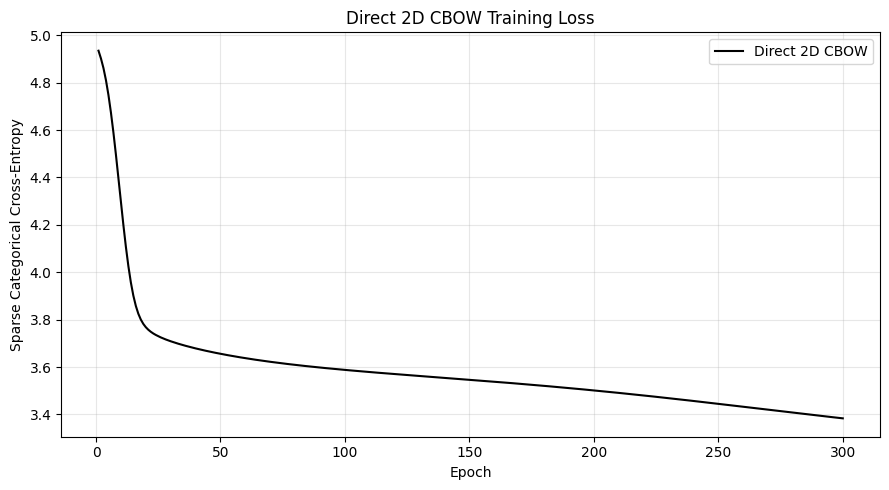

In [86]:
p5_epochs = np.arange(
    1,
    P5_EPOCHS + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    p5_epochs,
    cbow_2d_history.history["loss"],
    label="Direct 2D CBOW",
    color='k'
)

plt.xlabel("Epoch")
plt.ylabel("Sparse Categorical Cross-Entropy")
plt.title("Direct 2D CBOW Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
E5_2D = cbow_2d_model.get_layer(
    "embedding"
).get_weights()[0]

assert E5_2D.shape == (
    P5_VOCAB_SIZE,
    2
)

print(f"Direct embedding matrix shape is: {E5_2D.shape}")

Direct embedding matrix shape is: (141, 2)


* **2.4 Training**

In [88]:
p5_2d_start_time = time.perf_counter()

cbow_2d_history = cbow_2d_model.fit(
    X5_cbow,
    y5_cbow,
    epochs=P5_EPOCHS,
    batch_size=P5_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

p5_2d_training_time = (
    time.perf_counter() - p5_2d_start_time
)

assert len(cbow_2d_history.history["loss"]) == P5_EPOCHS

print("Direct 2D CBOW Training")
print("-" * 80)
print(f"Completed epochs are: {P5_EPOCHS}")
print(f"Training time is:     {p5_2d_training_time:.2f} seconds")
print(
    f"Final loss is:        "
    f"{cbow_2d_history.history['loss'][-1]:.4f}"
)
print(
    f"Final accuracy is:    "
    f"{cbow_2d_history.history['accuracy'][-1] * 100:.2f}%"
)

Direct 2D CBOW Training
--------------------------------------------------------------------------------
Completed epochs are: 300
Training time is:     28.24 seconds
Final loss is:        3.1793
Final accuracy is:    31.33%


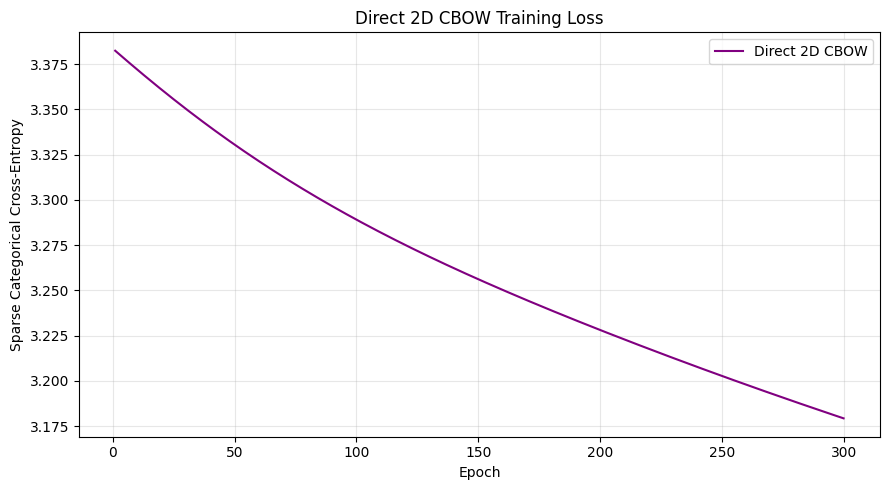

In [97]:
p5_epochs = np.arange(
    1,
    P5_EPOCHS + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    p5_epochs,
    cbow_2d_history.history["loss"],
    label="Direct 2D CBOW",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Sparse Categorical Cross-Entropy")
plt.title("Direct 2D CBOW Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* **3.4 Visualization**

In [90]:
E5_2D = cbow_2d_model.get_layer(
    "embedding"
).get_weights()[0]

assert E5_2D.shape == (
    P5_VOCAB_SIZE,
    2
)

print(f"Direct embedding matrix shape is: {E5_2D.shape}")

Direct embedding matrix shape is: (141, 2)


In [95]:
def plot_word_embeddings(
    coordinates,
    words,
    frequencies,
    title
):

    point_sizes = (
        20
        + 8 * np.log1p(frequencies)
    )

    plt.figure(figsize=(15, 11))

    plt.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        s=point_sizes,
        alpha=0.75,
        color='r'
    )

    for index, word in enumerate(words):
        plt.annotate(
            word,
            (
                coordinates[index, 0],
                coordinates[index, 1]
            ),
            fontsize=7,
            alpha=0.85
        )

    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.margins(0.08)
    plt.tight_layout()
    plt.show()

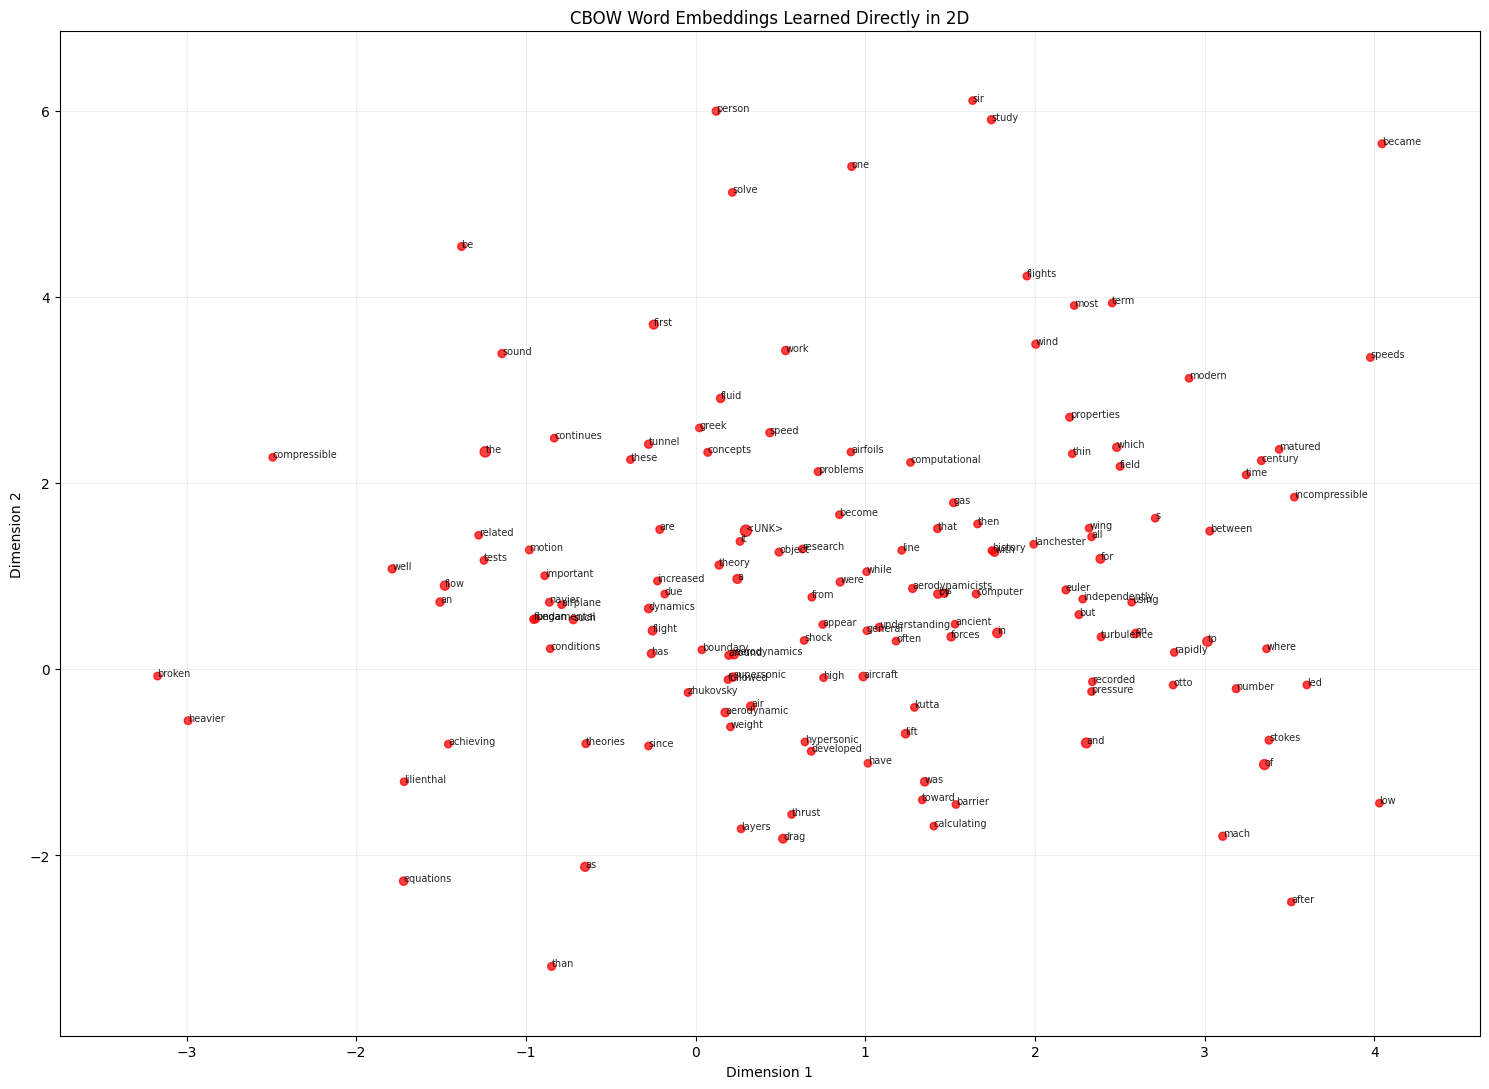

In [98]:
plot_word_embeddings(
    coordinates=E5_2D,
    words=p5_id_to_word,
    frequencies=p5_word_frequencies,
    title="CBOW Word Embeddings Learned Directly in 2D"
)

* **4.4 10D Embedding with PCA Reduction**

In [99]:
cbow_10d_model = build_cbow_model(
    vocab_size=P5_VOCAB_SIZE,
    embedding_dim=10
)

assert cbow_10d_model.input_shape == (
    None,
    P5_CONTEXT_SIZE
)

assert cbow_10d_model.output_shape == (
    None,
    P5_VOCAB_SIZE
)

cbow_10d_model.summary()

p5_10d_start_time = time.perf_counter()

cbow_10d_history = cbow_10d_model.fit(
    X5_cbow,
    y5_cbow,
    epochs=P5_EPOCHS,
    batch_size=P5_BATCH_SIZE,
    shuffle=True,
    verbose=0
)

p5_10d_training_time = (
    time.perf_counter() - p5_10d_start_time
)

assert len(cbow_10d_history.history["loss"]) == P5_EPOCHS

print("\n10D CBOW Training")
print("-" * 80)
print(f"Completed epochs are: {P5_EPOCHS}")
print(f"Training time is:     {p5_10d_training_time:.2f} seconds")
print(
    f"Final loss is:        "
    f"{cbow_10d_history.history['loss'][-1]:.4f}"
)
print(
    f"Final accuracy is:    "
    f"{cbow_10d_history.history['accuracy'][-1] * 100:.2f}%"
)

Model: "cbow_10d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ context (InputLayer)            │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 4, 10)          │         1,410 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ context_average                 │ (None, 10)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 141)            │         1,551 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,961 (11.57 KB)

 Trainable params: 2,961 (11.57 KB)

 Non-trainable params: 0 (0.00 B)


10D CBOW Training
--------------------------------------------------------------------------------
Completed epochs are: 300
Training time is:     31.11 seconds
Final loss is:        2.0066
Final accuracy is:    48.90%


In [100]:
E5_10D = cbow_10d_model.get_layer(
    "embedding"
).get_weights()[0]

assert E5_10D.shape == (
    P5_VOCAB_SIZE,
    10
)

print(f"10D embedding matrix shape is: {E5_10D.shape}")

10D embedding matrix shape is: (141, 10)


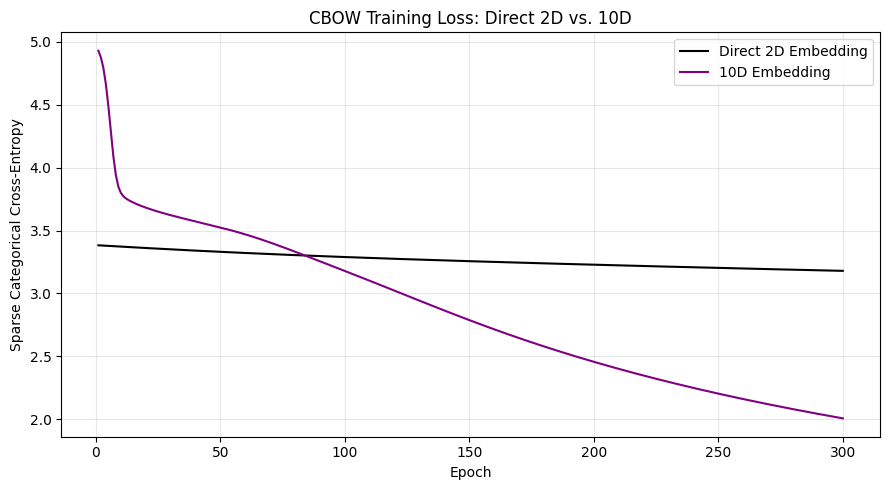

In [102]:
plt.figure(figsize=(9, 5))

plt.plot(
    p5_epochs,
    cbow_2d_history.history["loss"],
    label="Direct 2D Embedding",
    color='k'
)

plt.plot(
    p5_epochs,
    cbow_10d_history.history["loss"],
    label="10D Embedding",
    color='purple'
)

plt.xlabel("Epoch")
plt.ylabel("Sparse Categorical Cross-Entropy")
plt.title("CBOW Training Loss: Direct 2D vs. 10D")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [103]:
p5_pca = PCA(
    n_components=2
)

E5_PCA = p5_pca.fit_transform(
    E5_10D
)

assert E5_PCA.shape == (
    P5_VOCAB_SIZE,
    2
)

p5_pca_explained_variance = (
    p5_pca.explained_variance_ratio_
)

p5_pca_total_variance = float(
    p5_pca_explained_variance.sum()
)

print("PCA Projection Summary")
print("-" * 60)
print(f"Projected matrix shape is: {E5_PCA.shape}")
print(
    f"PC1 explained variance is: "
    f"{p5_pca_explained_variance[0] * 100:.2f}%"
)
print(
    f"PC2 explained variance is: "
    f"{p5_pca_explained_variance[1] * 100:.2f}%"
)
print(
    f"Total explained variance is: "
    f"{p5_pca_total_variance * 100:.2f}%"
)

PCA Projection Summary
------------------------------------------------------------
Projected matrix shape is: (141, 2)
PC1 explained variance is: 16.36%
PC2 explained variance is: 14.95%
Total explained variance is: 31.31%


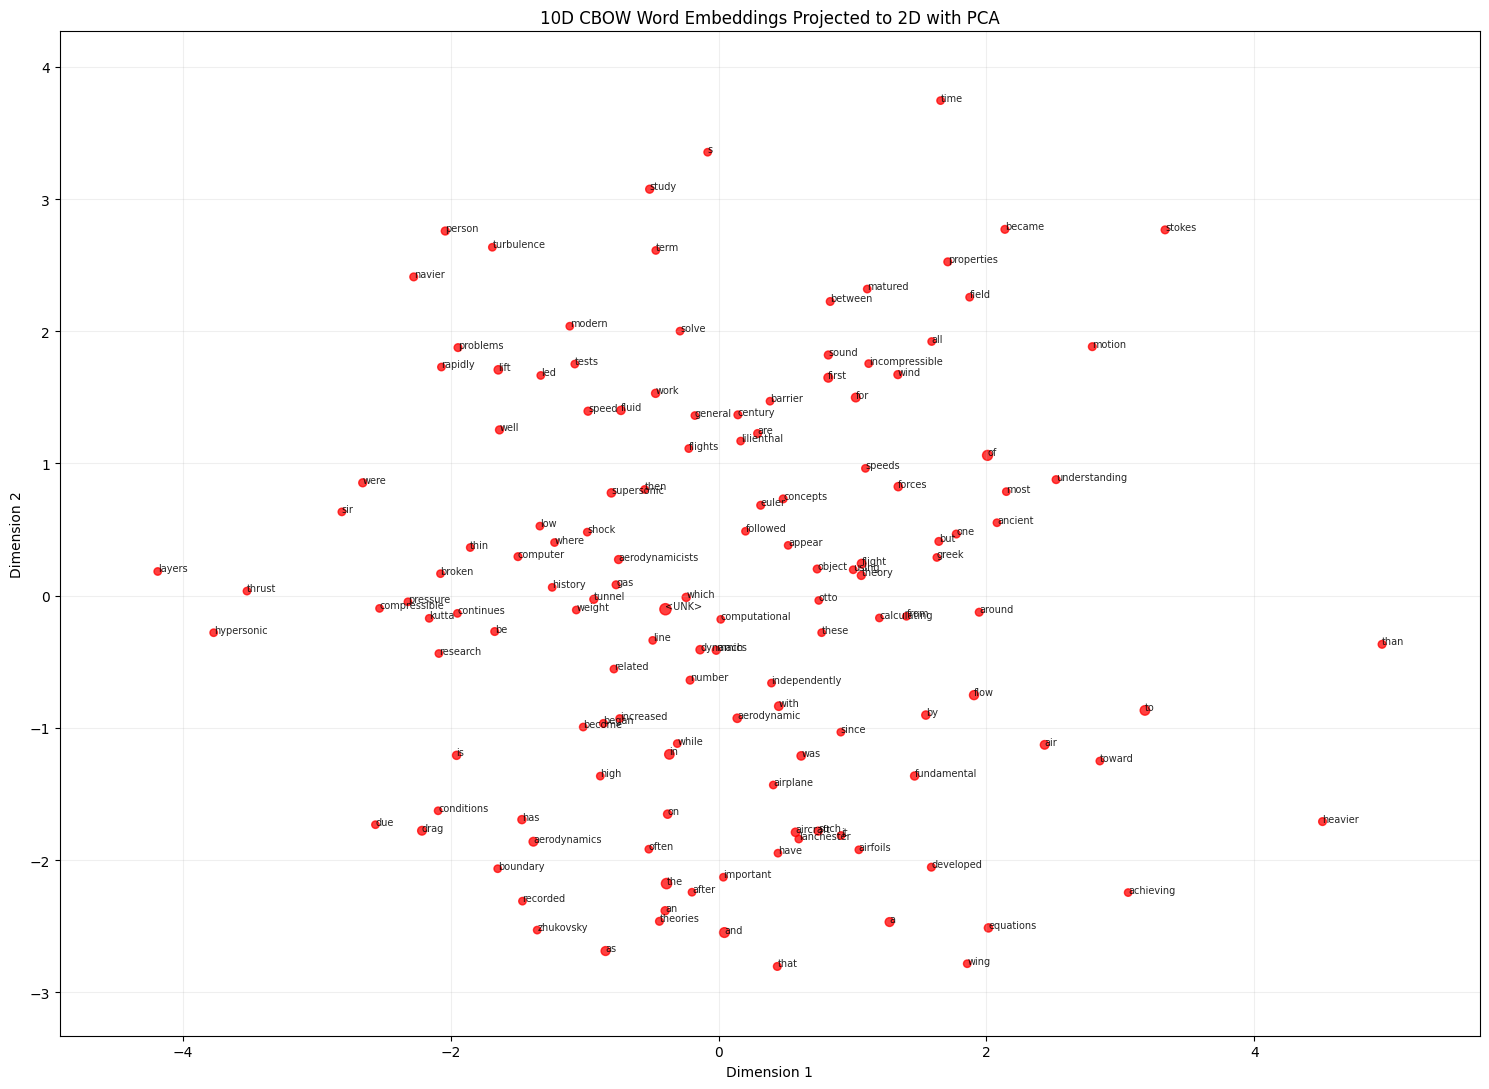

In [104]:
plot_word_embeddings(
    coordinates=E5_PCA,
    words=p5_id_to_word,
    frequencies=p5_word_frequencies,
    title="10D CBOW Word Embeddings Projected to 2D with PCA"
)

In [105]:
P5_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by",
    "for", "from", "has", "have", "in", "is", "it",
    "of", "on", "or", "that", "the", "their", "this",
    "to", "was", "were", "which", "with"
}


def find_nearest_words(
    embeddings,
    query_word,
    top_k=5
):

    query_index = p5_word_to_id[query_word]

    norms = np.linalg.norm(
        embeddings,
        axis=1,
        keepdims=True
    )

    normalized_embeddings = embeddings / np.maximum(
        norms,
        1e-12
    )

    similarities = (
        normalized_embeddings
        @ normalized_embeddings[query_index]
    )

    ranked_indices = np.argsort(
        similarities
    )[::-1]

    ranked_indices = [
        index
        for index in ranked_indices
        if index != query_index
    ][:top_k]

    return [
        (
            p5_id_to_word[index],
            similarities[index]
        )
        for index in ranked_indices
    ]


p5_query_words = [
    word
    for word, frequency in p5_raw_word_counts.most_common()
    if (
        word in p5_word_to_id
        and word not in P5_STOPWORDS
        and word != P5_UNK_TOKEN
    )
][:8]

p5_neighbor_rows = []

for query_word in p5_query_words:
    neighbors_2d = find_nearest_words(
        E5_2D,
        query_word
    )

    neighbors_10d = find_nearest_words(
        E5_10D,
        query_word
    )

    neighbors_pca = find_nearest_words(
        E5_PCA,
        query_word
    )

    p5_neighbor_rows.append({
        "Query Word": query_word,
        "Direct 2D Neighbors": ", ".join(
            word for word, _ in neighbors_2d
        ),
        "Original 10D Neighbors": ", ".join(
            word for word, _ in neighbors_10d
        ),
        "PCA 2D Neighbors": ", ".join(
            word for word, _ in neighbors_pca
        )
    })

p5_neighbor_df = pd.DataFrame(
    p5_neighbor_rows
)

display(p5_neighbor_df)

,Query Word,Direct 2D Neighbors,Original 10D Neighbors,PCA 2D Neighbors
0,flow,"well, has, began, fundamental, such","aircraft, computational, dynamics, airfoils, s...","heavier, these, toward, air, to"
1,first,"tunnel, are, greek, person, concepts","well, study, object, work, time","matured, euler, sound, time, followed"
2,aerodynamics,"matured, aerodynamicists, lanchester, century,...","sir, become, which, history, drag","increased, boundary, high, recorded, has"
3,drag,"weight, thrust, aerodynamic, layers, developed","kutta, thrust, number, hypersonic, after","conditions, related, line, due, become"
4,air,"hypersonic, calculating, developed, toward, have","from, achieving, greek, wing, but","toward, flow, heavier, these, by"
5,flight,"the, motion, dynamics, important, related","sound, wind, followed, heavier, these","but, using, one, ancient, object"
6,aerodynamic,"thrust, weight, drag, layers, developed","high, have, was, understanding, aerodynamicists","that, computational, have, airplane, and"
7,lift,"mach, followed, after, supersonic, low","supersonic, low, weight, thrust, between","navier, supersonic, problems, led, rapidly"


In [106]:
P5_NEIGHBOR_K = 5


def all_nearest_neighbor_indices(
    embeddings,
    top_k=5
):

    norms = np.linalg.norm(
        embeddings,
        axis=1,
        keepdims=True
    )

    normalized_embeddings = embeddings / np.maximum(
        norms,
        1e-12
    )

    similarities = (
        normalized_embeddings
        @ normalized_embeddings.T
    )

    np.fill_diagonal(
        similarities,
        -np.inf
    )

    return np.argsort(
        -similarities,
        axis=1
    )[:, :top_k]


def mean_neighbor_overlap(
    first_neighbors,
    second_neighbors
):

    overlap_scores = [
        len(
            set(first_neighbors[index])
            & set(second_neighbors[index])
        ) / first_neighbors.shape[1]
        for index in range(first_neighbors.shape[0])
    ]

    return float(
        np.mean(overlap_scores)
    )


p5_neighbors_2d = all_nearest_neighbor_indices(
    E5_2D,
    top_k=P5_NEIGHBOR_K
)

p5_neighbors_10d = all_nearest_neighbor_indices(
    E5_10D,
    top_k=P5_NEIGHBOR_K
)

p5_neighbors_pca = all_nearest_neighbor_indices(
    E5_PCA,
    top_k=P5_NEIGHBOR_K
)

p5_overlap_2d_10d = mean_neighbor_overlap(
    p5_neighbors_2d,
    p5_neighbors_10d
)

p5_overlap_10d_pca = mean_neighbor_overlap(
    p5_neighbors_10d,
    p5_neighbors_pca
)

p5_overlap_2d_pca = mean_neighbor_overlap(
    p5_neighbors_2d,
    p5_neighbors_pca
)

p5_overlap_df = pd.DataFrame({
    "Comparison": [
        "Direct 2D vs. Original 10D",
        "Original 10D vs. PCA 2D",
        "Direct 2D vs. PCA 2D"
    ],
    "Mean Top-5 Neighbor Overlap": [
        p5_overlap_2d_10d,
        p5_overlap_10d_pca,
        p5_overlap_2d_pca
    ]
})

display(
    p5_overlap_df.round(4)
)

,Comparison,Mean Top-5 Neighbor Overlap
0,Direct 2D vs. Original 10D,0.0879
1,Original 10D vs. PCA 2D,0.1149
2,Direct 2D vs. PCA 2D,0.0426


In [107]:
def final_loss_change(history, tail_epochs=20):

    tail_losses = np.asarray(
        history.history["loss"][-tail_epochs:]
    )

    return float(
        np.mean(
            np.abs(
                np.diff(tail_losses)
            )
        )
    )


p5_2d_final_loss_change = final_loss_change(
    cbow_2d_history
)

p5_10d_final_loss_change = final_loss_change(
    cbow_10d_history
)

p5_training_summary = pd.DataFrame({
    "Model": [
        "Direct 2D CBOW",
        "10D CBOW"
    ],
    "Parameters": [
        cbow_2d_model.count_params(),
        cbow_10d_model.count_params()
    ],
    "Training Time (s)": [
        p5_2d_training_time,
        p5_10d_training_time
    ],
    "Final Loss": [
        cbow_2d_history.history["loss"][-1],
        cbow_10d_history.history["loss"][-1]
    ],
    "Final Accuracy": [
        cbow_2d_history.history["accuracy"][-1],
        cbow_10d_history.history["accuracy"][-1]
    ],
    "Last-20 Mean Loss Change": [
        p5_2d_final_loss_change,
        p5_10d_final_loss_change
    ]
})

display(
    p5_training_summary.round(4)
)

,Model,Parameters,Training Time (s),Final Loss,Final Accuracy,Last-20 Mean Loss Change
0,Direct 2D CBOW,705,28.2421,3.1793,0.3133,0.0005
1,10D CBOW,2961,31.1131,2.0066,0.4890,0.0036


# 📌 Part 4 – CBOW Word Embedding Analysis

### **1️⃣ Training Performance**

The 10D CBOW model achieved substantially better target-word prediction than the direct 2D model:

| Model | Parameters | Training Time | Final Loss | Final Accuracy |
|---|---:|---:|---:|---:|
| Direct 2D CBOW | 705 | 28.24 s | 3.1793 | 31.33% |
| 10D CBOW | 2,961 | 31.11 s | 2.0066 | 48.90% |

Although the 10D model used approximately four times more parameters, its training time increased only slightly. Its lower loss and higher accuracy indicate that the higher-dimensional space captured contextual relationships more effectively.

### **2️⃣ Embedding Patterns**

The direct 2D representation formed several meaningful local relationships. For example, aerodynamic terms such as **drag**, **thrust**, **weight**, **lift**, and **aerodynamic** appeared relatively close to one another. However, many unrelated words also overlapped because all semantic information had to be represented using only two dimensions.

The original 10D embeddings generally produced more relevant neighbors for technical words. For instance, **flow** was associated with words such as **aircraft**, **computational**, **dynamics**, and **airfoils**, indicating improved representation of domain-specific context.

### **3️⃣ PCA Projection**

PCA provided a useful 2D visualization of the 10D embeddings, but some information was lost during projection. The mean top-5 neighbor overlap between the original 10D space and its PCA projection was only **11.49%**. The overlap between the direct 2D and PCA representations was even lower at **4.26%**, showing that the two models learned noticeably different geometric structures.

### **4️⃣ Interpretation**

The relatively weak and partially overlapping clusters are expected because the corpus contains only **1,000 words** and many vocabulary terms occur only a few times. The `<UNK>` token and frequent general-purpose words also influence the learned geometry.

> 💡 **Takeaway:**  
> The direct 2D model is easier to visualize but has limited representational capacity. The 10D model learns richer contextual relationships and achieves better predictive performance, while PCA offers an interpretable—but incomplete—2D view of that higher-dimensional embedding space.

In [ ]:
# Armin Amani